## EDA

In [39]:
# =========================
# [1] IMPORT + SETTINGS + PATH
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIBS_PATH  = "/Users/filipposaccomano/Downloads/Metabolomics data Mario Negri/FIBS_Single molecule_Feb26.xlsx"
MICRO_PATH = "/Users/filipposaccomano/Downloads/Metabolomics data Mario Negri/Microbiota_Single molecule_Feb26.xlsx"
SHEET_NAME = 0

TIMES = [1, 2, 3, 4]
MAX_PCT_FLOOR = 50.0

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [40]:
# =========================
# [2] LOAD FIBS: usa riga "Feature ID" come codici colonne metaboliti
# =========================
raw_f = pd.read_excel(FIBS_PATH, sheet_name=SHEET_NAME, header=None)

code_row = raw_f.iloc[0]                 # Feature ID (codici)
name_row = raw_f.iloc[1].astype(str)     # header (Code, Time, FI, ... + nomi metaboliti)
data_f   = raw_f.iloc[2:].copy()
data_f.columns = name_row

meta_cols_master = [
    "HMDB_Metabolite","Code","Time","FI","Sesso","BMI1",
    "C_renale","C_epatic10","AnniScuo","Subject"
]
meta_cols_fibs = [c for c in meta_cols_master if c in data_f.columns]

# rename: nome metabolita -> codice (stringa)
rename_fibs = {}
for j, col in enumerate(data_f.columns):
    if col in meta_cols_fibs:
        continue
    c = code_row.iloc[j]
    if pd.isna(c):
        continue
    try:
        f = float(c)
        c_str = str(int(f)) if f.is_integer() else str(f)
    except:
        c_str = str(c).strip()
    rename_fibs[col] = c_str

df_fibs = data_f.rename(columns=rename_fibs).copy()

# typing
for c in ["Code","Time","FI"]:
    if c in df_fibs.columns:
        df_fibs[c] = pd.to_numeric(df_fibs[c], errors="coerce")

df_fibs = df_fibs.dropna(subset=["Code","Time"]).copy()
df_fibs["Code"] = df_fibs["Code"].astype(int)
df_fibs["Time"] = df_fibs["Time"].astype(int)
df_fibs = df_fibs[df_fibs["Time"].isin(TIMES)].copy()

fibs_met_cols = [c for c in df_fibs.columns if c not in meta_cols_fibs]

print("FIBS shape:", df_fibs.shape)
print("FIBS metaboliti:", len(fibs_met_cols))

FIBS shape: (3342, 97)
FIBS metaboliti: 88


In [41]:
# =========================
# [3] LOAD MICROBIOTA: normalizza colonne + codici metaboliti come stringhe
# =========================
micro = pd.read_excel(MICRO_PATH, sheet_name=0, header=0)
micro.columns = [str(c).strip() for c in micro.columns]

# normalizza id/time
micro = micro.rename(columns={"TIME":"Time","time":"Time","ID Code":"Code","CODE":"Code","code":"Code"})

# se esistono colonne tipo Subject/ID inutili, le togliamo
micro = micro.drop(columns=[c for c in ["ID"] if c in micro.columns], errors="ignore").copy()

micro["Code"] = pd.to_numeric(micro["Code"], errors="coerce")
micro["Time"] = pd.to_numeric(micro["Time"], errors="coerce")
micro = micro.dropna(subset=["Code","Time"]).copy()

micro["Code"] = micro["Code"].astype(int)
micro["Time"] = micro["Time"].astype(int)
micro = micro[micro["Time"].isin(TIMES)].copy()

# normalizza nomi colonne metaboliti (es. 130604.0 -> "130604")
micro_met_cols = [c for c in micro.columns if c not in ["Code","Time", "Subject"]]

def norm_code(x):
    try:
        f = float(x)
        return str(int(f)) if f.is_integer() else str(f)
    except:
        return str(x).strip()

micro = micro.rename(columns={c: norm_code(c) for c in micro_met_cols})
micro_met_cols = [c for c in micro.columns if c not in ["Code","Time", "Subject"]]

# forza numerico nei metaboliti
micro[micro_met_cols] = micro[micro_met_cols].apply(pd.to_numeric, errors="coerce")

print("MICRO shape:", micro.shape)
print("MICRO metaboliti:", len(micro_met_cols))

MICRO shape: (3403, 110)
MICRO metaboliti: 107


In [42]:
# =========================
# [4] RIMUOVI DUPLICATI metaboliti: se codice esiste già in FIBS, lo tolgo da Microbiota
# =========================
dup_codes = sorted(list(set(micro_met_cols).intersection(set(fibs_met_cols))))
if dup_codes:
    print("Duplicati (stesso codice in FIBS e Microbiota) -> tolti da Microbiota:", dup_codes)
    micro = micro.drop(columns=dup_codes).copy()

micro_met_cols = [c for c in micro.columns if c not in ["Code","Time", "Subject"]]
print("MICRO metaboliti dopo dedup:", len(micro_met_cols))

Duplicati (stesso codice in FIBS e Microbiota) -> tolti da Microbiota: ['130604', '135585']
MICRO metaboliti dopo dedup: 105


In [43]:
# =========================
# [5] CONTROLLI PAZIENTI: tieni solo chi ha T1..T4 completi in ENTRAMBI (=> 609)
# =========================
def complete_codes(df_):
    n = df_.groupby("Code")["Time"].nunique()
    return set(n[n == len(TIMES)].index.astype(int))

cc_fibs  = complete_codes(df_fibs[["Code","Time"]])
cc_micro = complete_codes(micro[["Code","Time"]])
common   = sorted(list(cc_fibs & cc_micro))

print("Pazienti completi (T1..T4) FIBS:", len(cc_fibs))
print("Pazienti completi (T1..T4) MICRO:", len(cc_micro))
print("Intersezione (useremo questi):", len(common))

only_fibs = sorted(list(cc_fibs - cc_micro))
if only_fibs:
    print("Pazienti completi solo in FIBS (esclusi):", only_fibs)

df_fibs_c = df_fibs[df_fibs["Code"].isin(common)].copy()
micro_c   = micro[micro["Code"].isin(common)].copy()

# merge finale su Code-Time
df = df_fibs_c.merge(micro_c, on=["Code","Time"], how="inner")

print("\nDF finale (FIBS + Microbiota):", df.shape)
print("Pazienti:", df["Code"].nunique(), "| righe attese:", df["Code"].nunique()*4, "| righe reali:", len(df))
print("Time presenti:", sorted(df["Time"].unique()))

Pazienti completi (T1..T4) FIBS: 610
Pazienti completi (T1..T4) MICRO: 609
Intersezione (useremo questi): 609
Pazienti completi solo in FIBS (esclusi): [34]

DF finale (FIBS + Microbiota): (2436, 203)
Pazienti: 609 | righe attese: 2436 | righe reali: 2436
Time presenti: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [44]:
# =========================
# [6] CHECK HARD: ogni paziente deve avere esattamente [1,2,3,4]
# =========================
chk = df.groupby("Code")["Time"].apply(lambda s: sorted(s.unique()))
bad = chk[chk.apply(lambda t: t != TIMES)]

print("Pazienti con timepoint non perfetti:", bad.shape[0])
if bad.shape[0] > 0:
    display(bad.head(20))

Pazienti con timepoint non perfetti: 0


In [45]:
# =========================
# [7] DEFINISCI META VS METABOLITI (evita errori tipo 'Subject')
# =========================
meta_cols = [c for c in meta_cols_master if c in df.columns]
keep_meta = ["Code","Time"]
if "FI" in df.columns: 
    keep_meta.append("FI")

# aggiungi gli altri meta se presenti
for c in meta_cols:
    if c not in keep_meta:
        keep_meta.append(c)

met_cols_all = [c for c in df.columns if c not in keep_meta]

# forza numerico solo metaboliti
df[met_cols_all] = df[met_cols_all].apply(pd.to_numeric, errors="coerce")

print("Meta columns:", keep_meta)
print("Metaboliti totali:", len(met_cols_all))
print("Esempio metaboliti:", met_cols_all[:10])

Meta columns: ['Code', 'Time', 'FI', 'HMDB_Metabolite', 'Sesso', 'BMI1', 'C_renale', 'C_epatic10', 'AnniScuo', 'Subject']
Metaboliti totali: 193
Esempio metaboliti: ['133698', '139718', '126659', '106466', '135033', '126346', '103964', '113020', '82833', '99087']


In [46]:
# =========================
# [8] FILTER 1: TOGLI metaboliti con anche 1 solo NaN (stampa lista)
# =========================
nan_any = df[met_cols_all].isna().any(axis=0)

mets_with_nan = nan_any[nan_any].index.tolist()
mets_no_nan   = nan_any[~nan_any].index.tolist()

print("Metaboliti con >=1 NaN (da togliere):", len(mets_with_nan))
if len(mets_with_nan) > 0:
    print(mets_with_nan[:80], "..." if len(mets_with_nan) > 80 else "")

df_nn = df[keep_meta + mets_no_nan].copy()
met_cols_nn = mets_no_nan

print("Metaboliti rimasti senza NaN:", len(met_cols_nn))
print("df_nn shape:", df_nn.shape)

Metaboliti con >=1 NaN (da togliere): 0
Metaboliti rimasti senza NaN: 193
df_nn shape: (2436, 203)


In [47]:
# =========================
# [9] FILTER 2: floor = MIN del metabolita, togli %floor > 50
# =========================
# floor per colonna = minimo valore (ignora NaN, ma qui non ce ne sono)
floors = df_nn[met_cols_nn].min(axis=0)

# % valori uguali al floor
is_floor = df_nn[met_cols_nn].eq(floors, axis=1)
pct_floor = is_floor.mean(axis=0) * 100

mets_high_floor = pct_floor[pct_floor > MAX_PCT_FLOOR].index.tolist()
mets_ok_floor   = pct_floor[pct_floor <= MAX_PCT_FLOOR].index.tolist()

print("Metaboliti con %floor > 50 (da togliere):", len(mets_high_floor))
if len(mets_high_floor) > 0:
    print(mets_high_floor[:80], "..." if len(mets_high_floor) > 80 else "")

df_eda = df_nn[keep_meta + mets_ok_floor].copy()
met_cols_eda = mets_ok_floor

print("\nDF EDA finale:", df_eda.shape)
print("Metaboliti finali:", len(met_cols_eda))

Metaboliti con %floor > 50 (da togliere): 139
['133698', '139718', '126659', '106466', '135033', '126346', '103964', '113020', '99087', '119236', '168490', '138907', '120572', '117118', '117123', '127908', '115216', '140845', '95952', '132791', '131236', '110861', '168439', '148452', '115483', '133194', '97085', '132942', '139970', '148969', '139688', '95488', '125270', '145525', '143390', '139429', '69769', '70501', '88906', '99957', '100525', '105612', '107230', '115097', '125698', '128641', '132923', '141889', '142686', '154201', '154261', '154918', '173108', '182877', '192291', '199458', '207856', '13944', '52082', '62745', '65143', '65715', '65906', '68671', '72355', '74086', '75706', '75712', '75756', '80030', '84005', '86199', '86784', '89424', '91522', '97037', '97573', '102849', '103976', '105164'] ...

DF EDA finale: (2436, 64)
Metaboliti finali: 54


In [48]:
# =========================
# [9B] RINOMINA SOLO I METABOLITI FIBS: feature_id -> nome
# da fare DOPO i controlli EDA
# =========================

# ricostruisco la mappa feature_id -> nome da FIBS
raw_f = pd.read_excel(FIBS_PATH, sheet_name=SHEET_NAME, header=None)

feature_row = raw_f.iloc[0]              # feature IDs
name_row    = raw_f.iloc[1].astype(str)  # nomi metaboliti / header

meta_cols_master = [
    "HMDB_Metabolite","Code","Time","FI","Sesso","BMI1",
    "C_renale","C_epatic10","AnniScuo","Subject"
]

fibs_code_to_name = {}

for j in range(len(name_row)):
    nm = str(name_row.iloc[j]).strip()
    if nm in meta_cols_master:
        continue

    fid = feature_row.iloc[j]
    if pd.isna(fid):
        continue

    try:
        f = float(fid)
        fid_str = str(int(f)) if f.is_integer() else str(f)
    except:
        fid_str = str(fid).strip()

    fibs_code_to_name[fid_str] = nm

# rinomina solo le colonne presenti in df_eda e appartenenti a FIBS
rename_after_eda = {c: fibs_code_to_name[c] for c in met_cols_eda if c in fibs_code_to_name}

# controllo sicurezza: evita collisioni di nomi
name_counts = pd.Series(rename_after_eda.values()).value_counts()
dup_names = name_counts[name_counts > 1].index.tolist()

if len(dup_names) > 0:
    print("Attenzione: ci sono nomi duplicati in FIBS, li lascio come codice per sicurezza.")
    for old_code, new_name in list(rename_after_eda.items()):
        if new_name in dup_names:
            rename_after_eda[old_code] = old_code

df_eda = df_eda.rename(columns=rename_after_eda).copy()

# aggiorna lista metaboliti finali
met_cols_eda = [rename_after_eda.get(c, c) for c in met_cols_eda]

print("Metaboliti FIBS rinominati:", len(rename_after_eda))
print("Esempio:", list(rename_after_eda.items())[:10])
print("Numero metaboliti finali:", len(met_cols_eda))

Metaboliti FIBS rinominati: 31
Esempio: [('82833', '(2E,4E)-2,4-Hexadienoic acid (sorbic acid)'), ('74059', 'Benzoic acid'), ('99108', '3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;'), ('121811', 'Methylgallic acid-O-sulphate'), ('77320', 'Pyrogallol'), ('108360', '6-Hydroxypseudooxynicotine'), ('126673', '1-(2,6-Dihydroxy-4-methoxyphenyl)-3-phenyl-1-propanone'), ('119396', 'Carnosine'), ('107734', 'Hydroxycotinine'), ('114147', 'Caffeine')]
Numero metaboliti finali: 54


Pazienti: 609
Time: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Righe: 2436


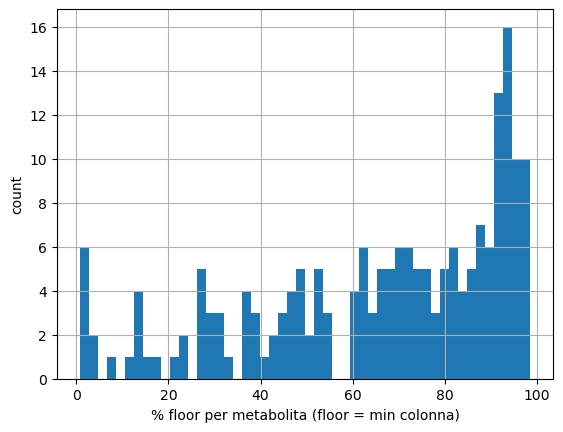

,pct_floor
143390,98.604269
154201,98.193760
88906,98.152709
173108,97.906404
105612,97.824302
133194,97.783251
132791,97.413793
134424,97.126437
122834,97.044335
132322,96.798030


In [49]:
# =========================
# [10] MINI-REPORT EDA: distribuzione %floor + sanity check
# =========================
print("Pazienti:", df_eda["Code"].nunique())
print("Time:", sorted(df_eda["Time"].unique()))
print("Righe:", len(df_eda))

plt.figure()
pct_floor.hist(bins=50)
plt.xlabel("% floor per metabolita (floor = min colonna)")
plt.ylabel("count")
plt.show()

# esempio: 10 metaboliti con più floor
top_floor = pct_floor.sort_values(ascending=False).head(10)
display(top_floor.to_frame("pct_floor"))

In [50]:
# =========================
# SANKEY frailty transitions nel tempo
# FI > 0.25 => frail, altrimenti not frail
# =========================

import pandas as pd
import numpy as np
import plotly.graph_objects as go

# --- copia e controlli base ---
df_sankey = df_eda.copy()

required_cols = ["Code", "Time", "FI"]
missing = [c for c in required_cols if c not in df_sankey.columns]
if missing:
    raise ValueError(f"Mancano queste colonne nel dataset: {missing}")

# tieni solo righe utili
df_sankey = df_sankey[["Code", "Time", "FI"]].dropna().copy()

# stato frailty
df_sankey["frailty_status"] = np.where(df_sankey["FI"] > 0.25, "frail", "not frail")

# ordina i timepoint in modo sensato
# prova a convertirli a numerico, se non riesce usa ordinamento lessicografico
time_num = pd.to_numeric(df_sankey["Time"], errors="coerce")
if time_num.notna().all():
    time_order = sorted(df_sankey["Time"].unique())
else:
    time_order = sorted(df_sankey["Time"].astype(str).unique(), key=lambda x: str(x))

# se Time non è già stringa per i label del grafico
df_sankey["Time_str"] = df_sankey["Time"].astype(str)

# tieni una sola riga per paziente-time se per caso ci fossero duplicati
# qui prendo la media di FI per sicurezza
df_sankey = (
    df_sankey
    .groupby(["Code", "Time", "Time_str"], as_index=False)["FI"]
    .mean()
)

df_sankey["frailty_status"] = np.where(df_sankey["FI"] > 0.25, "frail", "not frail")

# --- costruzione transizioni tra time consecutivi ---
flows = []

for t1, t2 in zip(time_order[:-1], time_order[1:]):
    a = (
        df_sankey[df_sankey["Time"] == t1][["Code", "frailty_status"]]
        .rename(columns={"frailty_status": "status_from"})
    )
    b = (
        df_sankey[df_sankey["Time"] == t2][["Code", "frailty_status"]]
        .rename(columns={"frailty_status": "status_to"})
    )
    
    ab = a.merge(b, on="Code", how="inner")  # solo pazienti presenti in entrambi i timepoint
    
    cnt = (
        ab.groupby(["status_from", "status_to"])
        .size()
        .reset_index(name="value")
    )
    cnt["time_from"] = str(t1)
    cnt["time_to"]   = str(t2)
    flows.append(cnt)

if len(flows) == 0:
    raise ValueError("Nessuna transizione trovata tra timepoint consecutivi.")

flows = pd.concat(flows, ignore_index=True)

# --- nodi ---
statuses = ["not frail", "frail"]
node_labels = []
for t in time_order:
    for s in statuses:
        node_labels.append(f"{t} | {s}")

node_to_idx = {lab: i for i, lab in enumerate(node_labels)}

# --- link source/target/value ---
sources = []
targets = []
values  = []
link_colors = []

for _, r in flows.iterrows():
    src = f"{r['time_from']} | {r['status_from']}"
    tgt = f"{r['time_to']} | {r['status_to']}"
    
    sources.append(node_to_idx[src])
    targets.append(node_to_idx[tgt])
    values.append(int(r["value"]))
    
    # colori dei flussi
    if r["status_from"] == "not frail" and r["status_to"] == "not frail":
        link_colors.append("rgba(100,149,237,0.35)")   # blu chiaro
    elif r["status_from"] == "frail" and r["status_to"] == "frail":
        link_colors.append("rgba(220,20,60,0.35)")     # rosso
    elif r["status_from"] == "not frail" and r["status_to"] == "frail":
        link_colors.append("rgba(255,140,0,0.45)")     # arancione
    else:
        link_colors.append("rgba(34,139,34,0.45)")     # verde

# colori nodi
node_colors = []
for lab in node_labels:
    if lab.endswith("not frail"):
        node_colors.append("cornflowerblue")
    else:
        node_colors.append("crimson")

# --- grafico ---
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=22,
        thickness=22,
        line=dict(color="black", width=0.5),
        label=node_labels,
        color=node_colors
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors
    )
)])

n_patients = df_sankey["Code"].nunique()

fig.update_layout(
    title=f"Sankey transitions frailty status over time (n={n_patients} pazienti)",
    font_size=12,
    width=1100,
    height=600
)

fig.show()

# tabella riassuntiva sotto
display(
    flows.sort_values(["time_from", "status_from", "status_to"]).reset_index(drop=True)
)

,status_from,status_to,value,time_from,time_to
0,not frail,frail,21,1,2
1,not frail,not frail,588,1,2
2,frail,frail,13,2,3
3,frail,not frail,8,2,3
4,not frail,frail,17,2,3
5,not frail,not frail,571,2,3
6,frail,frail,27,3,4
7,frail,not frail,3,3,4
8,not frail,frail,111,3,4
9,not frail,not frail,468,3,4


In [51]:
# =========================
# SANKEY: ever frail vs never frail lungo i timepoint
# ever frail = paziente con almeno un FI > 0.25 in qualunque visita
# never frail = paziente con FI <= 0.25 in tutte le visite
# =========================

import pandas as pd
import numpy as np
import plotly.graph_objects as go

df_sank = df_eda.copy()

required_cols = ["Code", "Time", "FI"]
missing = [c for c in required_cols if c not in df_sank.columns]
if missing:
    raise ValueError(f"Mancano queste colonne: {missing}")

df_sank = df_sank[["Code", "Time", "FI"]].dropna().copy()

# Se ci sono duplicati paziente-time, media FI
df_sank = (
    df_sank
    .groupby(["Code", "Time"], as_index=False)["FI"]
    .mean()
)

# stato al singolo timepoint
df_sank["status_time"] = np.where(df_sank["FI"] > 0.25, "frail", "not frail")

# gruppo paziente: ever frail / never frail
ever_map = (
    df_sank.groupby("Code")["FI"]
    .max()
    .gt(0.25)
    .map({True: "ever frail", False: "never frail"})
)

df_sank["group"] = df_sank["Code"].map(ever_map)

# ordina timepoint
time_num = pd.to_numeric(df_sank["Time"], errors="coerce")
if time_num.notna().all():
    time_order = sorted(df_sank["Time"].unique())
else:
    time_order = sorted(df_sank["Time"].astype(str).unique(), key=lambda x: str(x))

df_sank["Time_str"] = df_sank["Time"].astype(str)

# nodo = gruppo + stato nel timepoint
# es: "T1 | ever frail | frail"
node_labels = []
groups = ["never frail", "ever frail"]
statuses = ["not frail", "frail"]

for t in time_order:
    for g in groups:
        for s in statuses:
            node_labels.append(f"{t} | {g} | {s}")

node_to_idx = {lab: i for i, lab in enumerate(node_labels)}

# transizioni tra timepoint consecutivi
flows = []

for t1, t2 in zip(time_order[:-1], time_order[1:]):
    a = (
        df_sank[df_sank["Time"] == t1][["Code", "group", "status_time"]]
        .rename(columns={"status_time": "status_from"})
    )
    b = (
        df_sank[df_sank["Time"] == t2][["Code", "group", "status_time"]]
        .rename(columns={"status_time": "status_to"})
    )

    ab = a.merge(b, on=["Code", "group"], how="inner")

    cnt = (
        ab.groupby(["group", "status_from", "status_to"])
        .size()
        .reset_index(name="value")
    )
    cnt["time_from"] = str(t1)
    cnt["time_to"] = str(t2)
    flows.append(cnt)

if len(flows) == 0:
    raise ValueError("Nessuna transizione trovata tra timepoint consecutivi.")

flows = pd.concat(flows, ignore_index=True)

sources, targets, values, link_colors = [], [], [], []

for _, r in flows.iterrows():
    src = f"{r['time_from']} | {r['group']} | {r['status_from']}"
    tgt = f"{r['time_to']} | {r['group']} | {r['status_to']}"

    sources.append(node_to_idx[src])
    targets.append(node_to_idx[tgt])
    values.append(int(r["value"]))

    # colori link
    if r["group"] == "never frail":
        link_colors.append("rgba(100,149,237,0.35)")   # blu
    else:
        if r["status_from"] == "frail" and r["status_to"] == "frail":
            link_colors.append("rgba(220,20,60,0.40)")  # rosso
        elif r["status_from"] == "not frail" and r["status_to"] == "frail":
            link_colors.append("rgba(255,140,0,0.45)")  # arancione
        elif r["status_from"] == "frail" and r["status_to"] == "not frail":
            link_colors.append("rgba(34,139,34,0.45)")  # verde
        else:
            link_colors.append("rgba(160,32,240,0.35)") # viola

# colori nodi
node_colors = []
for lab in node_labels:
    if "never frail" in lab:
        node_colors.append("cornflowerblue")
    elif lab.endswith("not frail"):
        node_colors.append("mediumpurple")
    else:
        node_colors.append("crimson")

fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.4),
        label=node_labels,
        color=node_colors
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors
    )
)])

n_patients = df_sank["Code"].nunique()
n_ever = (ever_map == "ever frail").sum()
n_never = (ever_map == "never frail").sum()

fig.update_layout(
    title=(
        f"Sankey frailty trajectories by patient group "
        f"(n={n_patients}; ever frail={n_ever}, never frail={n_never})"
    ),
    font_size=11,
    width=1300,
    height=700
)

fig.show()

# tabella riassuntiva
display(
    flows.sort_values(["group", "time_from", "status_from", "status_to"]).reset_index(drop=True)
)

,group,status_from,status_to,value,time_from,time_to
0,ever frail,not frail,frail,21,1,2
1,ever frail,not frail,not frail,121,1,2
2,ever frail,frail,frail,13,2,3
3,ever frail,frail,not frail,8,2,3
4,ever frail,not frail,frail,17,2,3
5,ever frail,not frail,not frail,104,2,3
6,ever frail,frail,frail,27,3,4
7,ever frail,frail,not frail,3,3,4
8,ever frail,not frail,frail,111,3,4
9,ever frail,not frail,not frail,1,3,4


In [52]:
# =========================
# SANKEY: gruppi definiti dallo stato a T4
# group 1 = frail at T4
# group 2 = not frail at T4
# =========================

import pandas as pd
import numpy as np
import plotly.graph_objects as go

df_sank = df_eda.copy()

required_cols = ["Code", "Time", "FI"]
missing = [c for c in required_cols if c not in df_sank.columns]
if missing:
    raise ValueError(f"Mancano queste colonne: {missing}")

# tieni solo colonne utili
df_sank = df_sank[["Code", "Time", "FI"]].dropna().copy()

# se ci sono duplicati paziente-time, media FI
df_sank = (
    df_sank
    .groupby(["Code", "Time"], as_index=False)["FI"]
    .mean()
)

# stato a ogni timepoint
df_sank["status"] = np.where(df_sank["FI"] > 0.25, "frail", "not frail")

# ordinamento timepoint
time_num = pd.to_numeric(df_sank["Time"], errors="coerce")
if time_num.notna().all():
    time_order = sorted(df_sank["Time"].unique())
else:
    time_order = sorted(df_sank["Time"].astype(str).unique(), key=lambda x: str(x))

if len(time_order) < 2:
    raise ValueError("Servono almeno 2 timepoint per fare il Sankey.")

# definisco T4 come ultimo timepoint disponibile
t4 = time_order[-1]

# tengo solo pazienti che hanno T4
df_t4 = df_sank[df_sank["Time"] == t4][["Code", "status"]].copy()
df_t4["group"] = np.where(df_t4["status"] == "frail", "frail at T4", "not frail at T4")
group_map = dict(zip(df_t4["Code"], df_t4["group"]))

# assegna gruppo a tutto il dataset
df_sank["group"] = df_sank["Code"].map(group_map)

# tieni solo pazienti con T4 osservato
df_sank = df_sank.dropna(subset=["group"]).copy()

# per etichette
df_sank["Time_str"] = df_sank["Time"].astype(str)

# -------------------------
# NODI
# -------------------------
groups = ["not frail at T4", "frail at T4"]
statuses = ["not frail", "frail"]

node_labels = groups.copy()
for t in time_order:
    for s in statuses:
        node_labels.append(f"{t} | {s}")

node_to_idx = {lab: i for i, lab in enumerate(node_labels)}

sources = []
targets = []
values = []
link_colors = []

# -------------------------
# LINK 1: gruppo -> primo timepoint
# -------------------------
first_t = time_order[0]
df_first = df_sank[df_sank["Time"] == first_t].copy()

cnt_first = (
    df_first.groupby(["group", "status"])
    .size()
    .reset_index(name="value")
)

for _, r in cnt_first.iterrows():
    src = r["group"]
    tgt = f"{first_t} | {r['status']}"

    sources.append(node_to_idx[src])
    targets.append(node_to_idx[tgt])
    values.append(int(r["value"]))

    if r["group"] == "not frail at T4":
        link_colors.append("rgba(100,149,237,0.40)")   # blu
    else:
        link_colors.append("rgba(220,20,60,0.40)")     # rosso

# -------------------------
# LINK 2: transizioni tra timepoint consecutivi
# -------------------------
for t1, t2 in zip(time_order[:-1], time_order[1:]):
    a = (
        df_sank[df_sank["Time"] == t1][["Code", "status"]]
        .rename(columns={"status": "status_from"})
    )
    b = (
        df_sank[df_sank["Time"] == t2][["Code", "status"]]
        .rename(columns={"status": "status_to"})
    )

    ab = a.merge(b, on="Code", how="inner")

    cnt = (
        ab.groupby(["status_from", "status_to"])
        .size()
        .reset_index(name="value")
    )

    for _, r in cnt.iterrows():
        src = f"{t1} | {r['status_from']}"
        tgt = f"{t2} | {r['status_to']}"

        sources.append(node_to_idx[src])
        targets.append(node_to_idx[tgt])
        values.append(int(r["value"]))

        if r["status_from"] == "not frail" and r["status_to"] == "not frail":
            link_colors.append("rgba(100,149,237,0.30)")   # blu
        elif r["status_from"] == "frail" and r["status_to"] == "frail":
            link_colors.append("rgba(220,20,60,0.35)")     # rosso
        elif r["status_from"] == "not frail" and r["status_to"] == "frail":
            link_colors.append("rgba(255,140,0,0.40)")     # arancione
        else:
            link_colors.append("rgba(34,139,34,0.40)")     # verde

# -------------------------
# COLORI NODI
# -------------------------
node_colors = []
for lab in node_labels:
    if lab == "not frail at T4":
        node_colors.append("cornflowerblue")
    elif lab == "frail at T4":
        node_colors.append("lightcoral")
    elif lab.endswith("not frail"):
        node_colors.append("royalblue")
    else:
        node_colors.append("crimson")

# -------------------------
# FIGURA
# -------------------------
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=22,
        thickness=22,
        line=dict(color="black", width=0.4),
        label=node_labels,
        color=node_colors
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors
    )
)])

n_patients = df_sank["Code"].nunique()
n_frail_t4 = (df_t4["group"] == "frail at T4").sum()
n_not_frail_t4 = (df_t4["group"] == "not frail at T4").sum()

fig.update_layout(
    title=(
        f"Frailty trajectories by final status at T4 "
        f"(n={n_patients}; frail at T4={n_frail_t4}, not frail at T4={n_not_frail_t4})"
    ),
    font_size=12,
    width=1200,
    height=650
)

fig.show()

# -------------------------
# TABELLE RIASSUNTIVE
# -------------------------
print(f"T4 identificato come ultimo timepoint disponibile: {t4}")

print("\nPazienti per gruppo:")
display(
    pd.Series({
        "not frail at T4": n_not_frail_t4,
        "frail at T4": n_frail_t4
    }).to_frame("n_patients")
)

print(f"\nDistribuzione al primo timepoint ({first_t}):")
display(cnt_first.sort_values(["group", "status"]).reset_index(drop=True))

T4 identificato come ultimo timepoint disponibile: 4

Pazienti per gruppo:


,n_patients
not frail at T4,471
frail at T4,138



Distribuzione al primo timepoint (1):


,group,status,value
0,frail at T4,not frail,138
1,not frail at T4,not frail,471


In [53]:
# =========================
# OVERLAP tra:
# 1) ever frail
# 2) frail at T4
# =========================

import pandas as pd
import numpy as np

df_chk = df_eda.copy()

required_cols = ["Code", "Time", "FI"]
missing = [c for c in required_cols if c not in df_chk.columns]
if missing:
    raise ValueError(f"Mancano queste colonne: {missing}")

# tieni colonne utili e togli NA
df_chk = df_chk[["Code", "Time", "FI"]].dropna().copy()

# se ci sono duplicati paziente-time, media FI
df_chk = (
    df_chk
    .groupby(["Code", "Time"], as_index=False)["FI"]
    .mean()
)

# ordina timepoint
time_num = pd.to_numeric(df_chk["Time"], errors="coerce")
if time_num.notna().all():
    time_order = sorted(df_chk["Time"].unique())
else:
    time_order = sorted(df_chk["Time"].astype(str).unique(), key=lambda x: str(x))

t4 = time_order[-1]

# -------------------------
# gruppo 1: ever frail
# -------------------------
ever_frail_ids = set(
    df_chk.groupby("Code")["FI"]
    .max()
    .loc[lambda s: s > 0.25]
    .index
)

# -------------------------
# gruppo 2: frail at T4
# -------------------------
frail_t4_ids = set(
    df_chk.loc[(df_chk["Time"] == t4) & (df_chk["FI"] > 0.25), "Code"]
)

# -------------------------
# overlap
# -------------------------
common_ids = ever_frail_ids & frail_t4_ids
only_ever_ids = ever_frail_ids - frail_t4_ids
only_t4_ids = frail_t4_ids - ever_frail_ids

print(f"T4 identificato come: {t4}\n")

print(f"Ever frail: {len(ever_frail_ids)}")
print(f"Frail at T4: {len(frail_t4_ids)}")
print(f"In comune: {len(common_ids)}")
print(f"Solo ever frail: {len(only_ever_ids)}")
print(f"Solo frail at T4: {len(only_t4_ids)}")

# percentuali utili
print("\nPercentuali:")
print(f"% dei frail at T4 che sono anche ever frail: {100 * len(common_ids) / len(frail_t4_ids):.1f}%")
print(f"% degli ever frail che sono anche frail at T4: {100 * len(common_ids) / len(ever_frail_ids):.1f}%")

# tabella riassuntiva
summary_df = pd.DataFrame({
    "group": [
        "ever frail",
        "frail at T4",
        "common",
        "only ever frail",
        "only frail at T4"
    ],
    "n": [
        len(ever_frail_ids),
        len(frail_t4_ids),
        len(common_ids),
        len(only_ever_ids),
        len(only_t4_ids)
    ]
})

display(summary_df)

# opzionale: dataframe con appartenenza dei singoli pazienti
membership_df = pd.DataFrame({
    "Code": sorted(ever_frail_ids | frail_t4_ids),
})
membership_df["ever_frail"] = membership_df["Code"].isin(ever_frail_ids)
membership_df["frail_at_T4"] = membership_df["Code"].isin(frail_t4_ids)

display(membership_df.head(20))

# opzionale: liste ID
common_ids_sorted = sorted(common_ids)
only_ever_ids_sorted = sorted(only_ever_ids)
only_t4_ids_sorted = sorted(only_t4_ids)

print("\nPrimi 20 ID in comune:")
print(common_ids_sorted[:20])

print("\nPrimi 20 ID solo ever frail:")
print(only_ever_ids_sorted[:20])

print("\nPrimi 20 ID solo frail at T4:")
print(only_t4_ids_sorted[:20])

T4 identificato come: 4

Ever frail: 142
Frail at T4: 138
In comune: 138
Solo ever frail: 4
Solo frail at T4: 0

Percentuali:
% dei frail at T4 che sono anche ever frail: 100.0%
% degli ever frail che sono anche frail at T4: 97.2%


,group,n
0,ever frail,142
1,frail at T4,138
2,common,138
3,only ever frail,4
4,only frail at T4,0


,Code,ever_frail,frail_at_T4
0,19,True,True
1,37,True,True
2,71,True,True
3,82,True,True
4,89,True,True
5,93,True,True
6,109,True,True
7,116,True,True
8,121,True,True
9,142,True,True



Primi 20 ID in comune:
[19, 37, 71, 82, 89, 93, 109, 116, 121, 142, 148, 160, 172, 198, 205, 219, 220, 222, 226, 246]

Primi 20 ID solo ever frail:
[393, 559, 957, 1392]

Primi 20 ID solo frail at T4:
[]


frailty_group
not_frail    2247
frail         189
Name: count, dtype: int64
Numero metaboliti considerati: 54


,metabolite,floor_value,floor_%_frail,floor_%_not_frail,diff_pp,abs_diff_pp
0,86252,0.06,57.671958,34.757454,22.914503,22.914503
1,"1-(2,6-Dihydroxy-4-methoxyphenyl)-3-phenyl-1-p...",0.30,20.105820,39.652870,-19.547050,19.547050
2,Phloretin,0.46,45.502646,25.990209,19.512436,19.512436
3,Methylgallic acid-O-sulphate,0.08,65.079365,45.794393,19.284973,19.284973
4,Eicosadienoic acid (cis-20:2n-6),0.04,64.550265,46.016911,18.533353,18.533353
5,88195,0.64,32.804233,14.330218,18.474015,18.474015
6,Secoisolariciresinol,0.10,12.169312,30.529595,-18.360283,18.360283
7,Daidzein,0.72,48.677249,30.485091,18.192157,18.192157
8,Enterolactone; Enterolactone;,0.04,27.513228,43.925234,-16.412006,16.412006
9,Pinoresinol,0.10,11.640212,27.903872,-16.263660,16.263660


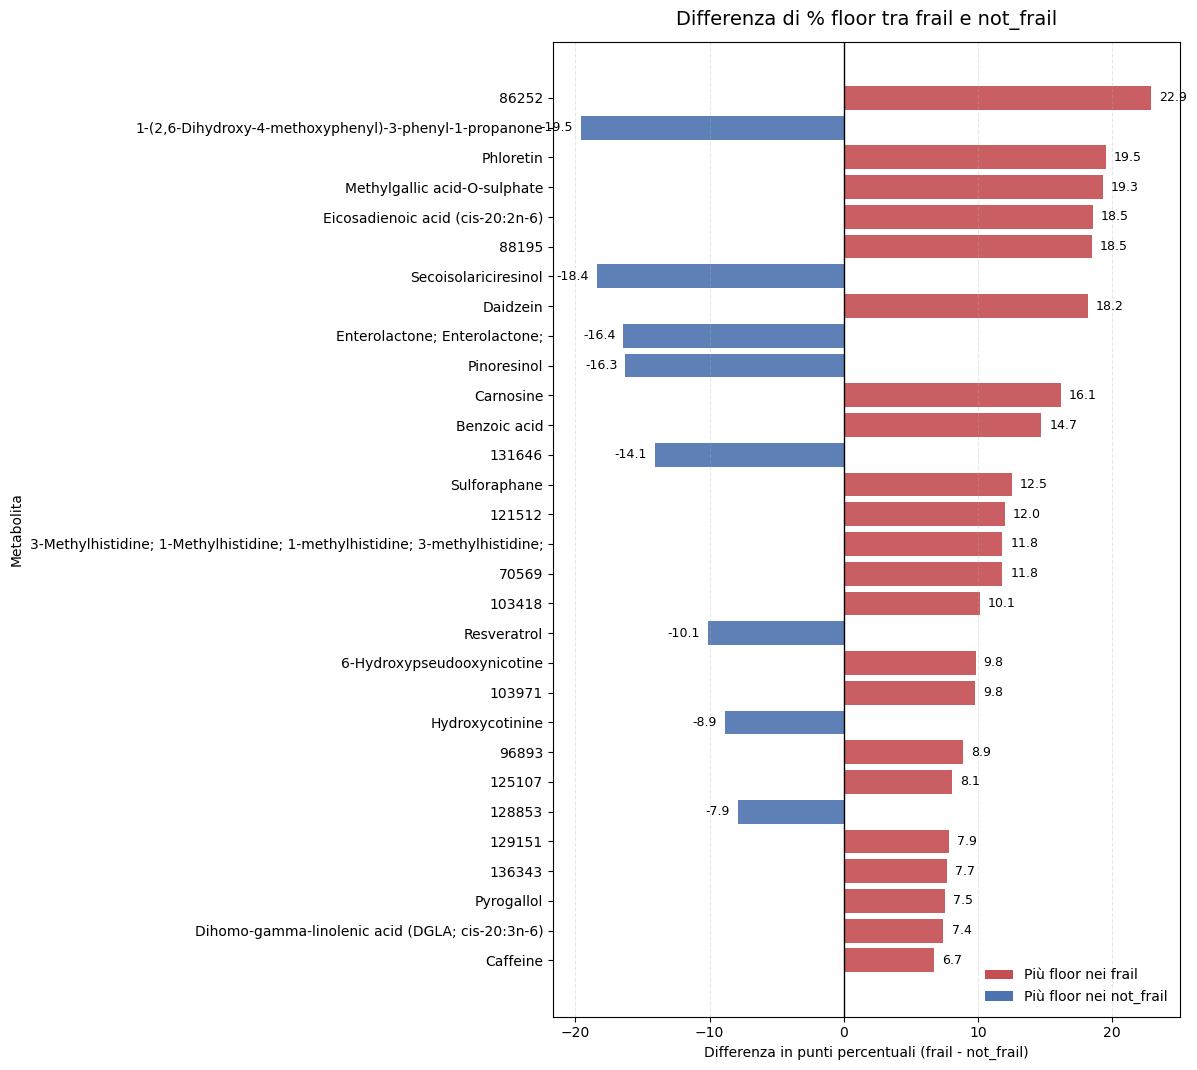

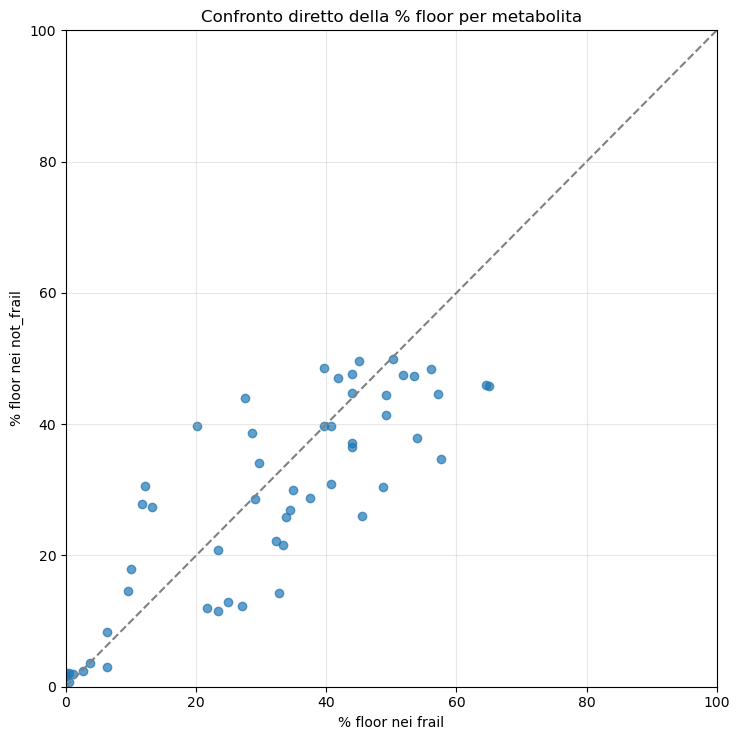

In [54]:
# ============================================================
# % FLOOR per metabolita nei gruppi definiti da FI
# frail = FI > 0.25
# not_frail = FI <= 0.25
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) DATAFRAME PULITO
# ------------------------------------------------------------
# Cambia qui se il tuo dataframe ha un altro nome
df_plot = df_eda.copy()

# ------------------------------------------------------------
# 2) CREA I GRUPPI DA FI
# ------------------------------------------------------------
if "FI" not in df_plot.columns:
    raise ValueError("Colonna 'FI' non trovata nel dataframe.")

df_plot["frailty_group"] = np.where(df_plot["FI"] > 0.25, "frail", "not_frail")

print(df_plot["frailty_group"].value_counts(dropna=False))

# ------------------------------------------------------------
# 3) IDENTIFICA LE COLONNE DEI METABOLITI
# ------------------------------------------------------------
exclude_cols = {
    "Code", "code", "ID", "id", "subject_id", "patient_id",
    "TIME", "time", "Time", "t_years", "FI", "frailty_group"
}

metabolite_cols = [
    c for c in df_plot.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df_plot[c])
]

print(f"Numero metaboliti considerati: {len(metabolite_cols)}")

# ------------------------------------------------------------
# 4) CALCOLO % FLOOR PER OGNI METABOLITA E PER OGNI GRUPPO
#    Definizione floor: valore minimo osservato del metabolita
# ------------------------------------------------------------
rows = []

for m in metabolite_cols:
    s = df_plot[m].dropna()
    if len(s) == 0:
        continue
    
    floor_val = s.min()

    s_frail = df_plot.loc[df_plot["frailty_group"] == "frail", m]
    s_not   = df_plot.loc[df_plot["frailty_group"] == "not_frail", m]

    n_frail = s_frail.notna().sum()
    n_not   = s_not.notna().sum()

    pct_frail = 100 * (s_frail == floor_val).sum() / n_frail if n_frail > 0 else np.nan
    pct_not   = 100 * (s_not == floor_val).sum() / n_not if n_not > 0 else np.nan

    rows.append({
        "metabolite": m,
        "floor_value": floor_val,
        "floor_%_frail": pct_frail,
        "floor_%_not_frail": pct_not,
        "diff_pp": pct_frail - pct_not,   # punti percentuali
        "abs_diff_pp": abs(pct_frail - pct_not)
    })

floor_group_df = (
    pd.DataFrame(rows)
    .sort_values("abs_diff_pp", ascending=False)
    .reset_index(drop=True)
)

display(floor_group_df.head(20))

# ------------------------------------------------------------
# 5) GRAFICO 1: BARPLOT DIFFERENZA % FLOOR
# ------------------------------------------------------------
TOPN = min(30, len(floor_group_df))
plot_df = floor_group_df.head(TOPN).copy()

# inverti per avere il più grande in alto nel barh
plot_df = plot_df.iloc[::-1]

colors = np.where(plot_df["diff_pp"] >= 0, "#c44e52", "#4c72b0")

fig, ax = plt.subplots(figsize=(12, max(7, TOPN * 0.36)))

bars = ax.barh(
    plot_df["metabolite"],
    plot_df["diff_pp"],
    color=colors,
    alpha=0.9
)

ax.axvline(0, color="black", linewidth=1)
ax.set_title("Differenza di % floor tra frail e not_frail", fontsize=14, pad=12)
ax.set_xlabel("Differenza in punti percentuali (frail - not_frail)")
ax.set_ylabel("Metabolita")

for bar, val in zip(bars, plot_df["diff_pp"]):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ha = "left" if x >= 0 else "right"
    offset = 0.6 if x >= 0 else -0.6
    ax.text(x + offset, y, f"{val:.1f}", va="center", ha=ha, fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#c44e52", label="Più floor nei frail"),
    Patch(facecolor="#4c72b0", label="Più floor nei not_frail")
]
ax.legend(handles=legend_elements, frameon=False, loc="lower right")

ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) GRAFICO 2: SCATTER % FLOOR FRAIL VS NOT_FRAIL
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 7.5))

x = floor_group_df["floor_%_frail"]
y = floor_group_df["floor_%_not_frail"]

ax.scatter(x, y, alpha=0.7)

lims = [
    min(x.min(), y.min(), 0),
    max(x.max(), y.max(), 100)
]
ax.plot(lims, lims, linestyle="--", color="gray")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("% floor nei frail")
ax.set_ylabel("% floor nei not_frail")
ax.set_title("Confronto diretto della % floor per metabolita")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Numero righe per gruppo:
frailty_group_patient
never_frail    1868
ever_frail      568
Name: count, dtype: int64

Numero pazienti per gruppo:
frailty_group_patient
never_frail    467
ever_frail     142
Name: count, dtype: int64

Numero metaboliti considerati: 54


,metabolite,floor_value,floor_%_ever_frail,floor_%_never_frail,diff_pp,abs_diff_pp
0,Methylgallic acid-O-sulphate,0.08,55.281690,44.860814,10.420876,10.420876
1,88195,0.64,23.415493,13.436831,9.978662,9.978662
2,136343,0.28,56.514085,46.734475,9.779609,9.779609
3,88933,0.06,37.852113,28.104925,9.747188,9.747188
4,Phloretin,0.46,33.802817,25.588865,8.213952,8.213952
5,Carnosine,0.02,45.070423,37.259101,7.811322,7.811322
6,Daidzein,0.72,26.056338,33.672377,-7.616039,7.616039
7,121512,0.70,19.366197,12.098501,7.267696,7.267696
8,129151,0.04,47.183099,40.364026,6.819073,6.819073
9,3-Methylhistidine; 1-Methylhistidine; 1-methyl...,1.60,17.605634,10.813704,6.791929,6.791929


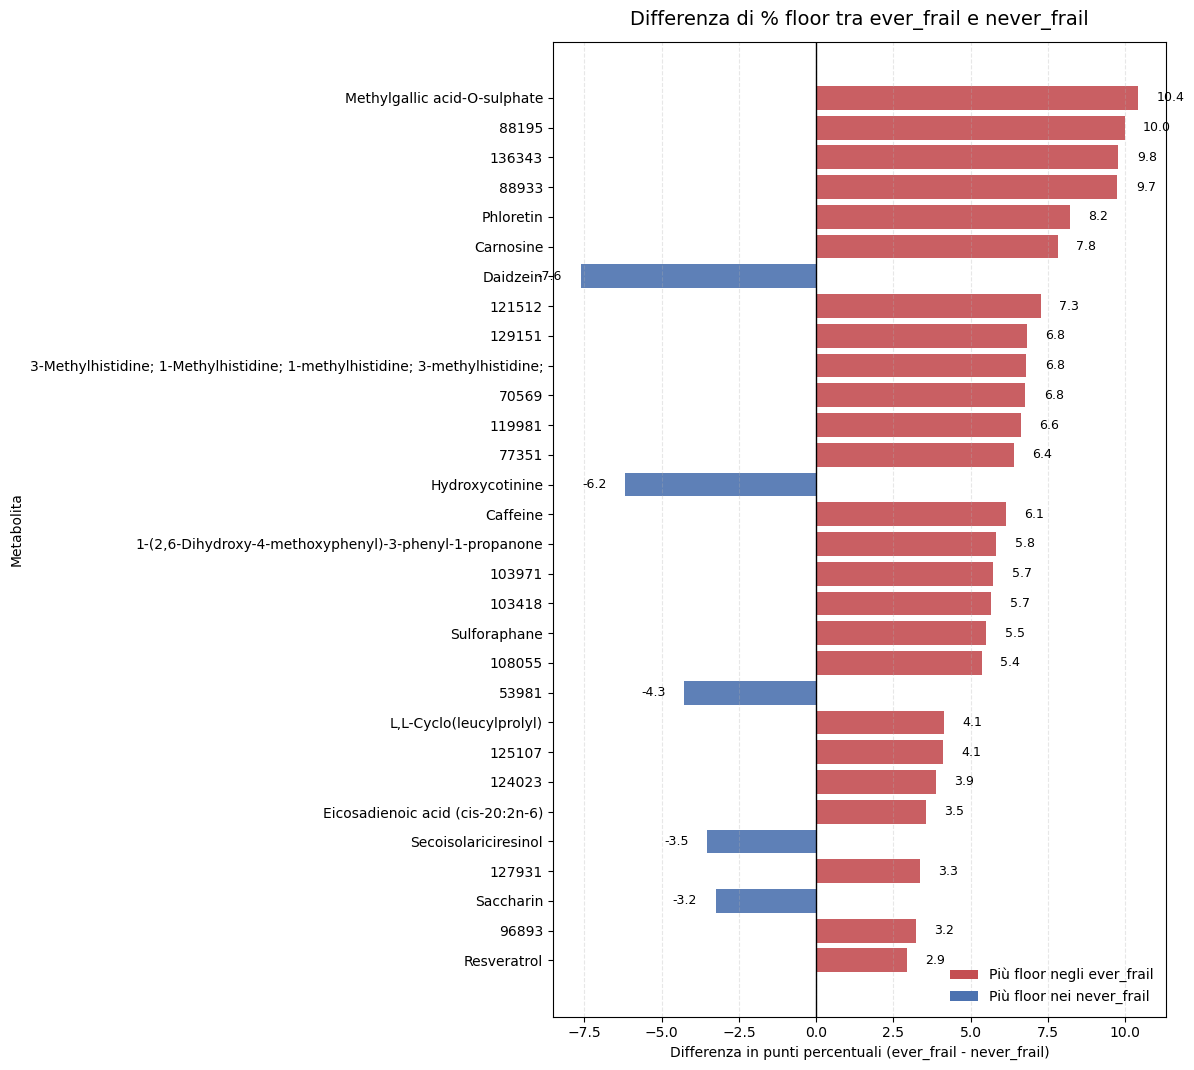

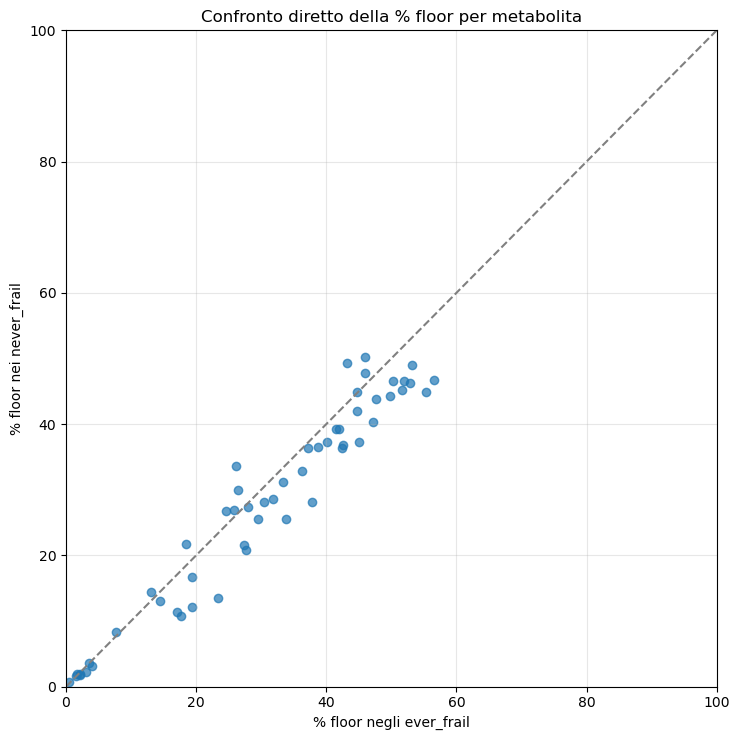

In [55]:
# ============================================================
# % FLOOR per metabolita nei gruppi EVER_FRAIL vs NEVER_FRAIL
# ever_frail = paziente con almeno un time point con FI > 0.25
# never_frail = paziente che non supera mai 0.25
# Tutti i time point del paziente ereditano il gruppo
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 1) DATAFRAME PULITO
# ------------------------------------------------------------
df_plot = df_eda.copy()

if "FI" not in df_plot.columns:
    raise ValueError("Colonna 'FI' non trovata.")
if "Code" not in df_plot.columns:
    raise ValueError("Colonna 'Code' non trovata.")

# ------------------------------------------------------------
# 2) CREA GRUPPO PAZIENTE: ever_frail / never_frail
# ------------------------------------------------------------
patient_group = (
    df_plot.groupby("Code")["FI"]
    .apply(lambda x: "ever_frail" if (x > 0.25).any() else "never_frail")
    .rename("frailty_group_patient")
)

df_plot = df_plot.merge(patient_group, on="Code", how="left")

print("Numero righe per gruppo:")
print(df_plot["frailty_group_patient"].value_counts(dropna=False))
print("\nNumero pazienti per gruppo:")
print(patient_group.value_counts(dropna=False))

# ------------------------------------------------------------
# 3) IDENTIFICA LE COLONNE METABOLITI
# ------------------------------------------------------------
exclude_cols = {
    "Code", "code", "ID", "id", "subject_id", "patient_id",
    "TIME", "time", "Time", "t_years", "FI",
    "frailty_group_patient"
}

metabolite_cols = [
    c for c in df_plot.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df_plot[c])
]

print(f"\nNumero metaboliti considerati: {len(metabolite_cols)}")

# ------------------------------------------------------------
# 4) CALCOLO % FLOOR PER OGNI METABOLITA E PER OGNI GRUPPO
#    Definizione floor: valore minimo osservato del metabolita
# ------------------------------------------------------------
rows = []

for m in metabolite_cols:
    s_all = df_plot[m].dropna()
    if len(s_all) == 0:
        continue

    floor_val = s_all.min()

    s_ever  = df_plot.loc[df_plot["frailty_group_patient"] == "ever_frail", m]
    s_never = df_plot.loc[df_plot["frailty_group_patient"] == "never_frail", m]

    n_ever  = s_ever.notna().sum()
    n_never = s_never.notna().sum()

    pct_ever  = 100 * (s_ever  == floor_val).sum() / n_ever  if n_ever  > 0 else np.nan
    pct_never = 100 * (s_never == floor_val).sum() / n_never if n_never > 0 else np.nan

    rows.append({
        "metabolite": m,
        "floor_value": floor_val,
        "floor_%_ever_frail": pct_ever,
        "floor_%_never_frail": pct_never,
        "diff_pp": pct_ever - pct_never,   # punti percentuali
        "abs_diff_pp": abs(pct_ever - pct_never)
    })

floor_group_patient_df = (
    pd.DataFrame(rows)
    .sort_values("abs_diff_pp", ascending=False)
    .reset_index(drop=True)
)

display(floor_group_patient_df.head(20))

# ------------------------------------------------------------
# 5) GRAFICO 1: BARPLOT differenza % floor
# ------------------------------------------------------------
TOPN = min(30, len(floor_group_patient_df))
plot_df = floor_group_patient_df.head(TOPN).copy().iloc[::-1]

colors = np.where(plot_df["diff_pp"] >= 0, "#c44e52", "#4c72b0")

fig, ax = plt.subplots(figsize=(12, max(7, TOPN * 0.36)))

bars = ax.barh(
    plot_df["metabolite"],
    plot_df["diff_pp"],
    color=colors,
    alpha=0.9
)

ax.axvline(0, color="black", linewidth=1)
ax.set_title("Differenza di % floor tra ever_frail e never_frail", fontsize=14, pad=12)
ax.set_xlabel("Differenza in punti percentuali (ever_frail - never_frail)")
ax.set_ylabel("Metabolita")

for bar, val in zip(bars, plot_df["diff_pp"]):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ha = "left" if x >= 0 else "right"
    offset = 0.6 if x >= 0 else -0.6
    ax.text(x + offset, y, f"{val:.1f}", va="center", ha=ha, fontsize=9)

legend_elements = [
    Patch(facecolor="#c44e52", label="Più floor negli ever_frail"),
    Patch(facecolor="#4c72b0", label="Più floor nei never_frail")
]
ax.legend(handles=legend_elements, frameon=False, loc="lower right")

ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) GRAFICO 2: scatter % floor ever_frail vs never_frail
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 7.5))

x = floor_group_patient_df["floor_%_ever_frail"]
y = floor_group_patient_df["floor_%_never_frail"]

ax.scatter(x, y, alpha=0.7)

lims = [
    min(x.min(), y.min(), 0),
    max(x.max(), y.max(), 100)
]
ax.plot(lims, lims, linestyle="--", color="gray")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("% floor negli ever_frail")
ax.set_ylabel("% floor nei never_frail")
ax.set_title("Confronto diretto della % floor per metabolita")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## tcam

In [56]:
# ============================================
# [TCAM1] IMPORT + CARTELLE
# ============================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mprod import table2tensor
from mprod.dimensionality_reduction import TCAM

OUTDIR = "tcam_outputs_all_mets"
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(f"{OUTDIR}/tables", exist_ok=True)
os.makedirs(f"{OUTDIR}/figures", exist_ok=True)

EPS = 1e-9
TIME_ORDER = [1, 2, 3, 4]

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

KeyError: 'e'

In [ ]:
# ============================================
# [TCAM2] DATASET LONG CON TUTTI I METABOLITI
# robusto: controlla tipi, completezza e duplicati
# ============================================
use_cols = ["Code", "Time", "FI"] + list(met_cols_all)

df_tcam = df[use_cols].copy()

# conversioni numeriche
df_tcam["Code"] = pd.to_numeric(df_tcam["Code"], errors="coerce")
df_tcam["Time"] = pd.to_numeric(df_tcam["Time"], errors="coerce")
df_tcam["FI"]   = pd.to_numeric(df_tcam["FI"], errors="coerce")
df_tcam[met_cols_all] = df_tcam[met_cols_all].apply(pd.to_numeric, errors="coerce")

# tieni solo righe con Code e Time validi
df_tcam = df_tcam.dropna(subset=["Code", "Time"]).copy()
df_tcam["Code"] = df_tcam["Code"].astype(int)
df_tcam["Time"] = df_tcam["Time"].astype(int)

# tieni solo i 4 time point desiderati
df_tcam = df_tcam[df_tcam["Time"].isin(TIME_ORDER)].copy()

print("Shape iniziale:", df_tcam.shape)
print("Pazienti iniziali:", df_tcam["Code"].nunique())

# controlla duplicati Code-Time
dup_mask = df_tcam.duplicated(subset=["Code", "Time"], keep=False)
n_dup_rows = dup_mask.sum()
print("Righe coinvolte in duplicati Code-Time:", n_dup_rows)

if n_dup_rows > 0:
    print("\nEsempio duplicati:")
    display(
        df_tcam.loc[dup_mask, ["Code", "Time", "FI"]]
        .sort_values(["Code", "Time"])
        .head(20)
    )

# se esistono duplicati, tieni la prima riga
# se vuoi un altro criterio, si può cambiare
df_tcam = (
    df_tcam
    .sort_values(["Code", "Time"])
    .drop_duplicates(subset=["Code", "Time"], keep="first")
    .copy()
)

# tieni solo soggetti completi T1..T4
chk = df_tcam.groupby("Code")["Time"].apply(lambda s: sorted(s.unique()))
good_codes = chk[chk.apply(lambda x: x == TIME_ORDER)].index.tolist()

df_tcam = df_tcam[df_tcam["Code"].isin(good_codes)].copy()
df_tcam = df_tcam.sort_values(["Code", "Time"]).reset_index(drop=True)

print("\nDopo filtro completezza:")
print("Shape df_tcam:", df_tcam.shape)
print("Pazienti completi:", df_tcam["Code"].nunique())
print("Time presenti:", sorted(df_tcam["Time"].unique()))
print("Metaboliti:", len(met_cols_all))

# check finali
chk_final = df_tcam.groupby("Code")["Time"].apply(lambda s: sorted(s.unique()))
assert chk_final.apply(lambda x: x == TIME_ORDER).all(), "Ci sono soggetti non completi."

dup_final = df_tcam.duplicated(subset=["Code", "Time"]).sum()
print("Duplicati Code-Time finali:", dup_final)
assert dup_final == 0, "Ci sono ancora duplicati Code-Time."

Shape iniziale: (2436, 196)
Pazienti iniziali: 609
Righe coinvolte in duplicati Code-Time: 0

Dopo filtro completezza:
Shape df_tcam: (2436, 196)
Pazienti completi: 609
Time presenti: [1, 2, 3, 4]
Metaboliti: 193
Duplicati Code-Time finali: 0


In [ ]:
# ============================================
# [TCAM3] EVER FRAIL vs NEVER FRAIL
# ============================================
FRAIL_THR = 0.25

ever_frail_map = (
    df_tcam.groupby("Code")["FI"]
    .apply(lambda s: (s > FRAIL_THR).any())
    .to_dict()
)

df_tcam["frail_group"] = df_tcam["Code"].map(
    lambda x: "Ever-frail" if ever_frail_map[x] else "Never-frail"
)

group_counts = (
    df_tcam[["Code", "frail_group"]]
    .drop_duplicates()["frail_group"]
    .value_counts()
)

print(group_counts)
display(df_tcam.head())

frail_group
Never-frail    467
Ever-frail     142
Name: count, dtype: int64


,Code,Time,FI,133698,139718,126659,106466,135033,126346,103964,113020,82833,99087,119236,74059,168490,99108,138907,121811,120572,117118,117123,127908,115216,77320,140845,108360,126673,95952,132791,131236,110861,168439,119396,107734,114147,126338,131116,130604,148452,115483,133194,97085,132942,139970,112827,148969,135585,139688,102818,95488,126961,125270,119670,138928,145525,143390,102381,98644,146389,96492,139429,69769,70501,88906,99957,100525,105611,105612,106160,107230,107747,115097,115109,125698,128641,132923,141889,142686,154201,154261,154918,154982,155702,156439,159176,173108,182877,192291,199458,207856,13944,52082,53981,62745,65143,65715,65906,68671,70569,72355,74086,75706,75712,75756,77351,80030,84005,86199,86252,86784,88195,88933,89424,91522,97037,97573,102849,103418,103971,103976,105164,107237,108055,108316,108945,111333,113218,117151,119788,119981,121399,121512,122342,122834,122847,123687,123743,124023,124157,124481,125107,125734,126048,126456,126683,127738,127924,127931,127942,127949,128253,128853,129151,129319,129795,130376,130381,130592,130809,131646,132322,132324,133960,134424,135436,135573,135910,136343,136611,136614,136851,138147,141191,142168,142174,142644,144134,144502,146373,146387,146438,146712,147158,149547,150916,153041,155288,157136,168129,190097,192859,206004,247273,96893,125401,frail_group
0,9,1,0.060606,0.04,0.08,0.12,0.24,0.58,0.04,0.02,0.12,234.60,0.1,0.04,3639.20,0.06,6492.7,0.02,873.40,15.40,0.14,295.00,0.04,0.1,1.46,0.04,569.60,0.3,86.30,0.06,1.74,3.26,24.30,176.40,0.02,0.06,2280.9,1602.3,0.04,0.96,0.02,4.36,0.06,0.06,0.82,0.06,3.38,54.7,0.86,0.06,0.12,2698.30,0.02,0.06,208.7,0.04,1.5,10302.30,18152.1,250.10,6964.7,3.78,0.22,0.04,38.64,0.04,0.06,1.2,4.6,207.2,9309874.00,0.16,0.1,2.26,0.02,2.22,0.06,0.28,0.1,0.12,0.02,0.48,0.66,0.06,0.04,5.84,1.6,0.22,4.0,0.66,0.98,3.44,0.78,52863.60,0.24,1.18,0.36,1.52,1.62,4199.30,0.24,31.84,1.32,0.08,1.4,0.02,0.04,0.22,0.5,0.06,569.40,1914.10,0.06,0.42,0.02,186.90,0.6,0.52,0.08,8718.0,0.2,0.02,4.18,17.70,1.02,0.6,0.1,0.22,0.76,0.12,291.70,6.0,13179.9,43.8,0.34,0.22,25.70,0.02,318.20,0.12,0.06,124.80,0.34,0.06,0.1,0.16,0.16,1.28,842.90,0.34,0.02,0.12,0.02,1561.70,3.72,39.2,0.26,0.16,0.02,0.82,0.14,7.98,2.02,97856.4,0.84,4.68,0.02,0.12,0.28,1.06,0.28,0.2,292.60,0.02,0.06,0.08,0.14,42.70,0.08,0.06,0.06,0.34,0.02,0.02,0.4,0.02,0.08,0.1,6.88,0.2,0.04,0.06,0.02,15506805.00,0.88,0.08,Never-frail
1,9,2,0.060606,39.50,0.08,527.00,0.24,0.58,107.00,0.02,0.12,0.04,0.1,0.04,3262.80,187.80,6380.9,0.02,0.08,0.02,55.20,88.80,66.90,0.1,3127.70,0.04,79.70,0.3,37.30,0.06,1.74,3.26,2.46,124.30,77.70,0.06,9678.2,144.8,0.04,0.96,0.02,4.36,28.30,36.70,0.82,40.10,3.38,0.1,0.86,124.70,0.12,10247.40,0.02,199.50,0.1,0.04,1.5,10901.60,5879.2,110.40,9701.6,3.78,0.22,0.04,38.64,2.50,0.06,12410.5,4.6,85151.5,3.82,607.40,0.1,80.00,0.02,185.00,0.06,0.28,1401.3,0.12,3830.90,0.48,46178.00,12552.10,7353.70,18494.20,1.6,0.22,4.0,0.66,0.98,3.44,0.78,1.94,0.24,1.18,0.36,1.52,1.62,128.70,0.24,31.84,1.32,0.08,1.4,67.80,0.04,0.22,0.5,747.30,0.04,1257.20,0.06,0.42,0.02,0.12,0.6,799.30,140.90,748.1,355.0,0.02,678.00,90.30,1.02,0.6,58.9,0.22,0.76,0.12,0.22,5040.8,5254.0,31.8,0.34,167.90,4.30,0.02,73.70,0.12,0.06,153.00,0.34,70.70,0.1,0.16,0.16,1.28,60.50,0.34,0.02,0.12,436.90,33.40,3.72,39.2,0.26,0.16,0.02,0.82,43.80,7.98,2.02,121.3,0.84,4.68,0.02,0.12,756.60,1636.30,0.28,0.2,0.24,276.30,0.06,34.70,0.14,0.34,0.08,30.50,0.06,0.34,0.02,0.02,0.4,0.02,0.08,0.1,3675.60,0.2,0.04,0.06,0.02,1.56,3210.50,751.70,Never-frail
2,9,3,0.060606,0.04,569.80,0.12,0.24,9375.30,0.04,0.02,0.12,1211857.70,0.1,0.04,996.90,0.06,6249.1,0.02,0.08,0.02,147835.00,0.34,232.50,0.1,167126.80,0.04,0.02,0.3,0.02,0.06,6219.00,3.26,2.46,0.02,98.70,22483.20,996.8,3678.7,522.40,0.96,0.02,4.36,0.06,2106.60,0.82,0.06,3.38,356848.7,0.86,0.06,0.12,34104.90,0.02,0.06,14146.8,0.04,1.5,0.02,2505.9,0.52,7834.5,3.78,0.22,0.04,38.64,0.04,0.06,16438.2,4.6,68943.1,3.82,893.70,18.4,1397.00,118.60,2859.40,82.60,0.28,0.1,0.12,0.02,0.48,2824.00,193.70,0.04,

In [ ]:
# ============================================
# [TCAM4] CONTROLLO MISSING METABOLITI
# scegliamo solo metaboliti completi per TCAM
# ============================================
mets_all = list(met_cols_all)

missing_per_met = df_tcam[mets_all].isna().sum().sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "n_missing": missing_per_met,
    "pct_missing": 100 * missing_per_met / len(df_tcam)
})

print("Metaboliti totali:", len(mets_all))
print("Metaboliti con almeno 1 NaN:", (missing_per_met > 0).sum())
display(missing_summary.head(20))

# tieni solo metaboliti senza NaN
mets = missing_per_met[missing_per_met == 0].index.tolist()

print("\nMetaboliti usati in TCAM (senza missing):", len(mets))
print("Metaboliti esclusi per missing:", len(mets_all) - len(mets))

excluded_mets = [m for m in mets_all if m not in mets]
if len(excluded_mets) > 0:
    display(pd.DataFrame({"excluded_metabolites": excluded_mets}).head(20))

Metaboliti totali: 193
Metaboliti con almeno 1 NaN: 0


,n_missing,pct_missing
133698,0,0.0
72355,0,0.0
111333,0,0.0
113218,0,0.0
117151,0,0.0
119788,0,0.0
119981,0,0.0
121399,0,0.0
121512,0,0.0
122342,0,0.0



Metaboliti usati in TCAM (senza missing): 193
Metaboliti esclusi per missing: 0


In [ ]:
# ============================================
# [TCAM5] NORMALIZZAZIONE
# log10(x + EPS) + baseline centering su T1
# ============================================
EPS = 1e-9

df_work = df_tcam[["Code", "Time", "FI", "frail_group"] + mets].copy()

# sicurezza: eventuali valori negativi diventano 0
neg_count = (df_work[mets] < 0).sum().sum()
print("Valori negativi trovati:", int(neg_count))

if neg_count > 0:
    df_work[mets] = df_work[mets].clip(lower=0)

# log transform
X_log = np.log10(df_work[mets] + EPS)

df_log = pd.concat(
    [df_work[["Code", "Time", "FI", "frail_group"]], X_log],
    axis=1
)

# baseline T1
baseline_log = (
    df_log[df_log["Time"] == 1]
    .drop(columns=["Time", "FI", "frail_group"])
    .set_index("Code")
)

# check: un baseline per soggetto
assert baseline_log.index.nunique() == df_log["Code"].nunique(), "Baseline T1 non univoco per soggetto."

# baseline centering
df_norm = df_log.copy()
for m in mets:
    df_norm[m] = df_log[m] - df_log["Code"].map(baseline_log[m])

# check T1 ~ 0
t1_max_abs = df_norm[df_norm["Time"] == 1][mets].abs().max().max()
print("Max |valore| a T1 dopo baseline-centering:", t1_max_abs)

display(df_norm.head())

Valori negativi trovati: 0
Max |valore| a T1 dopo baseline-centering: 0.0


,Code,Time,FI,frail_group,133698,72355,111333,113218,117151,119788,119981,121399,121512,122342,122834,122847,123687,123743,124023,124157,124481,125107,125734,126048,126456,126683,127738,108945,108316,108055,88195,75706,75712,75756,77351,80030,84005,86199,86252,86784,88933,107237,89424,91522,97037,97573,102849,103418,103971,103976,105164,127924,127931,127942,149547,142174,142644,144134,144502,146373,146387,146438,146712,147158,150916,141191,153041,155288,157136,168129,190097,192859,206004,247273,96893,142168,138147,127949,131646,128253,128853,129151,129319,129795,130376,130381,130592,130809,132322,136851,132324,133960,134424,135436,135573,135910,136343,136611,136614,74086,70569,139718,68671,132791,131236,110861,168439,119396,107734,114147,126338,131116,130604,148452,115483,133194,97085,132942,139970,112827,148969,135585,139688,102818,95952,126673,108360,74059,126659,106466,135033,126346,103964,113020,82833,99087,119236,168490,140845,99108,138907,121811,120572,117118,117123,127908,115216,77320,95488,126961,125270,182877,142686,154201,154261,154918,154982,155702,156439,159176,173108,192291,132923,199458,207856,13944,52082,53981,62745,65143,65715,65906,141889,128641,119670,70501,138928,145525,143390,102381,98644,146389,96492,139429,69769,88906,125698,99957,100525,105611,105612,106160,107230,107747,115097,115109,125401
0,9,1,0.060606,Never-frail,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,9,2,0.060606,Never-frail,2.994537,0.000000,2.770115,0.0,0.0,0.0,-3.122514,2.924348,-0.399422,-0.139047,0.0,2.882628,-0.776465,0.000000,-0.635233,0.0,0.0,0.088477,0.0,3.071268,0.0,0.0,0.000000,0.000000,0.0,0.707714,-0.182560,0.0,0.000000,0.0,3.5302,0.0,0.000000,0.000000,4.095344,-4.153357,0.00000,2.210053,0.0,0.000000,-3.192428,0.000000,3.186706,3.245821,-1.066457,3.249198,0.000000,0.000000,-1.144021,0.000000,0.0,2.637239,0.0,-2.098949,0.0,2.706149,0.000000,0.0,0.0,0.000000,0.0,4.140351,0.000000,0.000000,2.72774,0.0,0.0,0.0,0.000000,-6.997398,3.562090,0.000000,-3.086063,0.0,2.495346,0.000000,4.339352,-1.669851,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,-2.906728,0.0,0.000000,0.0,0.0,3.431708,3.188557,0.000000,0.000000,-1.513598,0.000000,0.000000,0.0,0.000000,0.0,-0.994671,-0.152027,3.589391,0.000000,0.627688,-1.043975,0.000000,0.000000,0.0,0.0,2.673635,2.786515,0.0,2.824993,0.0,-2.737987,0.000000,3.317715,-0.364302,0.000000,-0.854112,-0.047415,3.642629,0.000000,0.000000,3.427324,0.0,0.0,-3.768268,0.0,0.0,3.495544,0.0,-0.007543,0.000000,-4.038123,-2.886491,2.595811,-0.521409,3.223366,0.0,3.330872,0.0,0.579523,0.0,0.0,4.146531,0.0,5.282271,0.0,4.844891,5.320565,5.264446,3.500623,0

In [ ]:
# ============================================
# [TCAM7] TABELLA MULTIINDEX PER MPROD
# ============================================
data_table = (
    df_norm
    .set_index(["Code", "Time"])[mets]
    .sort_index()
    .copy()
)

print("Shape data_table:", data_table.shape)
display(data_table.head())

# salvataggio
data_table.to_csv(f"{OUTDIR}/tables/data_table_baseline_centered.tsv", sep="\t")

Shape data_table: (2436, 193)


133698     72355    111333  113218  117151  119788    119981  \
Code Time                                                                   
9    1     0.000000  0.000000  0.000000     0.0     0.0     0.0  0.000000   
     2     2.994537  0.000000  2.770115     0.0     0.0     0.0 -3.122514   
     3     0.000000  5.201078  0.000000     0.0     0.0     0.0 -3.122514   
     4     0.000000  0.000000  3.253096     0.0     0.0     0.0 -0.016539   
11   1     0.000000  0.000000  0.000000     0.0     0.0     0.0  0.000000   

             121399    121512    122342  122834    122847    123687    123743  \
Code Time                                                                       
9    1     0.000000  0.000000  0.000000     0.0  0.000000  0.000000  0.000000   
     2     2.924348 -0.399422 -0.139047     0.0  2.882628 -0.776465  0.000000   
     3     3.069724 -4.274814  1.816771     0.0  5.928261 -2.631782  0.000000   
     4     3.239483 -4.274814  1.366956     0.0  0.000000 -2.631782  3.559907   
11   1     0.000000  0.000000  0.000000     0.0  0.000000  0.000000  0.000000   

             124023  124157  124481    125107  125734    126048  126456  \
Code Time                                                                 
9    1     0.000000     0.0     0.0  0.000000     0.0  0.000000     0.0   
     2    -0.635233     0.0     0.0  0.088477     0.0  3.071268     0.0   
     3    -4.201670     0.0     0.0 -3.795185     0.0  0.000000     0.0   
     4    -4.201670     0.0     0.0 -3.795185     0.0  0.000000     0.0   
11   1     0.000000     0.0     0.0  0.000000     0.0  0.000000     0.0   

           126683    127738    108945  108316    108055     88195  75706  \
Code Time                                                                  
9    1        0.0  0.000000  0.000000     0.0  0.000000  0.000000    0.0   
     2        0.0  0.000000  0.000000     0.0  0.707714 -0.182560    0.0   
     3        0.0  3.475490  0.000000     0.0 -2.344883 -3.475785    0.0   
     4        0.0  2.212521  2.523313     0.0 -2.344883 -3.475785    0.0   
11   1        0.0  0.000000  0.000000     0.0  0.000000  0.000000    0.0   

              75712  75756   77351  80030     84005     86199     86252  \
Code Time                                                                 
9    1     0.000000    0.0  0.0000    0.0  0.000000  0.000000  0.000000   
     2     0.000000    0.0  3.5302    0.0  0.000000  0.000000  4.095344   
     3     2.055951    0.0  0.0000    0.0  5.385223  5.167881  0.000000   
     4     0.000000    0.0  0.0000    0.0  0.000000  2.973590  3.218360   
11   1     0.000000    0.0  0.0000    0.0  0.000000  0.000000  0.000000   

              86784    88933    107237  89424     91522     97037     97573  \
Code Time                                                                     
9    1     0.000000  0.00000  0.000000    0.0  0.000000  0.000000  0.000000   
     2    -4.153357  0.00000  2.210053    0.0  0.000000 -3.192428  0.000000   
     3    -0.566489  0.00000  2.435271    0.0  0.000000 -3.192428  4.337542   
     4    -4.153357  3.83495  2.698575    0.0  3.847264 -0.092345  3.706675   
11   1     0.000000  0.00000  0.000000    0.0  0.000000  0.000000  0.000000   

             102849    103418    103971    103976    105164    127924  \
Code Time                                                               
9    1     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
     2     3.186706  3.245821 -1.066457  3.249198  0.000000  0.000000   
     3     0.000000  0.000000 -3.861236  0.000000  2.934498  2.393027   
     4     0.000000  0.000000 -3.861236  0.000000  5.016908  2.303736   
11   1     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

             127931    127942  149547    142174  142644    144134  144502  \
Code Time                                                                   
9    1     0.000000  0.000000     0.0  0.000000     0.0  0.000000     0.0   
     2    -1.144021  0.

In [ ]:
# ============================================
# [TCAM8] TABLE -> TENSOR
# ============================================
data_tensor, map_subject, map_time = table2tensor(data_table)

print("Tensor shape:", data_tensor.shape)
print("n_subjects:", len(map_subject))
print("n_timepoints:", len(map_time))

# check attesi
assert data_tensor.shape[0] == df_norm["Code"].nunique(), "Mismatch numero soggetti."
assert data_tensor.shape[1] == len(mets), "Mismatch numero metaboliti."
assert data_tensor.shape[2] == len(TIME_ORDER), "Mismatch numero time point."

Tensor shape: (609, 193, 4)
n_subjects: 609
n_timepoints: 4


In [ ]:
# ============================================
# [TCAM9] FIT TCAM
# ============================================
tcam = TCAM()
scores = tcam.fit_transform(data_tensor)

print("Scores shape:", scores.shape)
print("Numero componenti:", scores.shape[1])

expl_var = pd.Series(
    tcam.explained_variance_ratio_,
    index=[f"F{i+1}" for i in range(len(tcam.explained_variance_ratio_))]
)

display(expl_var.to_frame("explained_variance_ratio").head(10))

Scores shape: (609, 771)
Numero componenti: 771


,explained_variance_ratio
F1,0.039907
F2,0.029699
F3,0.026253
F4,0.023253
F5,0.021747
F6,0.019898
F7,0.016137
F8,0.015387
F9,0.013711
F10,0.013684


In [ ]:
# ============================================
# [TCAM10] SCORES + METADATI
# ============================================
inv_subject_map = {v: k for k, v in map_subject.items()}

scores_df = pd.DataFrame(
    scores,
    index=[inv_subject_map[i] for i in range(scores.shape[0])],
    columns=[f"F{i+1}" for i in range(scores.shape[1])]
)

scores_df.index.name = "Code"
scores_df = scores_df.reset_index()

group_df = df_norm[["Code", "frail_group"]].drop_duplicates()
scores_df = scores_df.merge(group_df, on="Code", how="left")

display(scores_df.head())

scores_df.to_csv(f"{OUTDIR}/tables/tcam_scores_by_subject.tsv", sep="\t", index=False)
expl_var.to_csv(f"{OUTDIR}/tables/tcam_explained_variance.tsv", sep="\t")

,Code,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28,F29,F30,F31,F32,F33,F34,F35,F36,F37,F38,F39,F40,F41,F42,F43,F44,F45,F46,F47,F48,F49,F50,F51,F52,F53,F54,F55,F56,F57,F58,F59,F60,F61,F62,F63,F64,F65,F66,F67,F68,F69,F70,F71,F72,F73,F74,F75,F76,F77,F78,F79,F80,F81,F82,F83,F84,F85,F86,F87,F88,F89,F90,F91,F92,F93,F94,F95,F96,F97,F98,F99,...,F673,F674,F675,F676,F677,F678,F679,F680,F681,F682,F683,F684,F685,F686,F687,F688,F689,F690,F691,F692,F693,F694,F695,F696,F697,F698,F699,F700,F701,F702,F703,F704,F705,F706,F707,F708,F709,F710,F711,F712,F713,F714,F715,F716,F717,F718,F719,F720,F721,F722,F723,F724,F725,F726,F727,F728,F729,F730,F731,F732,F733,F734,F735,F736,F737,F738,F739,F740,F741,F742,F743,F744,F745,F746,F747,F748,F749,F750,F751,F752,F753,F754,F755,F756,F757,F758,F759,F760,F761,F762,F763,F764,F765,F766,F767,F768,F769,F770,F771,frail_group
0,9,-16.450199,-13.556959,8.971287,-2.201353,-13.944891,-2.271053,2.801092,13.097336,-5.298900,1.199882,-5.841548,4.552101,5.575284,0.718749,5.696050,3.938536,-8.418165,0.084863,-9.187510,-5.623812,-3.781598,2.737659,4.320069,-1.180963,-2.271753,-0.655126,0.429363,1.001358,-2.537644,-3.757999,1.955602,0.501721,-1.964543,0.293033,-1.418806,-1.452183,0.636283,1.602760,-7.075724,0.063883,1.101910,-2.096252,0.335671,-3.370757,3.247746,7.359339,0.263100,-2.540144,5.221663,0.467591,-7.558397,0.373965,0.999191,1.680485,0.153203,-0.246818,1.836582,-0.617174,-0.045555,-3.161264,-1.469184,1.361034,-4.091471,2.815308,-3.786077,-0.165129,1.385550,1.171097,5.676590,0.755108,3.098584,2.010891,1.942010,2.843367,1.954245,-0.830665,0.797433,2.463103,0.919790,-0.811031,4.975532,-0.598473,0.005246,1.608557,-3.799609,-0.790441,-2.712902,0.009491,0.269781,1.103374,1.060332,-0.749320,-1.016460,-1.741187,-4.858500,2.479726,-0.902959,-8.142028,3.617118,...,-0.245268,-0.614062,-0.004602,-0.035918,0.088493,-0.107816,-0.192152,-0.114778,0.044741,0.233921,0.153941,0.299499,-0.084178,0.270454,-0.291257,0.702139,-0.567681,-0.078015,-0.350464,-0.389166,-0.043250,-0.196177,-0.371310,-0.086998,-0.183005,0.384709,0.753100,-0.206308,-0.238365,-0.171907,0.405516,-0.515007,-0.104231,-0.012481,-0.253218,0.705705,-0.089089,-0.289182,0.377189,-0.209505,0.187155,-0.355163,-0.152518,0.292184,-0.001404,-0.235074,0.284805,0.171666,-0.304862,-0.249526,0.116745,-0.158417,0.108241,-0.337638,-0.071877,-0.183435,0.232038,-0.121409,0.363736,-0.048162,0.174443,-0.141372,0.072460,-0.341354,0.044387,0.046625,-0.175332,-0.197291,0.146779,0.391671,0.363556,-0.103210,0.078944,-0.127867,-0.143951,0.094954,0.299229,0.199625,0.141579,-0.078490,-0.078977,-0.006801,-0.126517,-0.102617,0.209159,-0.166483,-0.319837,-0.011718,0.169416,-0.103978,-0.156568,0.063538,0.045498,0.076436,0.006704,0.143102,-0.034646,-0.077762,-0.072851,Never-frail
1,11,-2.472003,3.958442,5.536397,-5.351396,-2.797690,5.025203,-5.460186,-7.243327,-3.094634,-4.499750,5.054581,6.133294,-1.206328,-3.084206,-6.511453,-0.615702,4.844760,0.246209,1.469608,-0.028055,-0.154883,4.179737,4.799509,2.199794,-1.621132,0.446347,3.309952,-1.582817,-5.943112,7.012008,-7.462229,3.845173,1.828714,-0.264439,-0.575876,3.072394,2.571901,1.515325,1.273316,-2.498087,1.412282,0.467769,0.008865,-1.730910,-4.568029,3.021640,0.475459,6.154534,2.073585,0.471932,-0.806318,-0.467484,-1.535626,1.397165,2.882891,-2.914138,-0.069178,-3.355584,2.326441,-1.841774,4.113017,-3.005257,-1.922668,-0.863407,1.746389,-2.065600,1.419260,-6.127839,0.262708,2.063757,-1.074573,-2.395333,-1.424480,1.120801,-0.690066,0.371322,0.010859,1.688389,-3.005863,-1.692785,-0.669139,1.564750,-2.961690,3.138223,2.261649,1.214814,-0.996996,-1.820350,-0.121448,-5.442571,-1.136482,-2.699972,1.162697,3.639999,-1.167848,-1.047209,1.247315,1.769338,-0.947308,...,0.114625,0.287111,-0.301523,-0.229288,-0.534565,-0.068982,-0.065346,-0.978919,0.187629,0.495454,0.053427,0.152917,0.451868,0.868824,-0.250723,-0.289526,-0.047906,0.160731,-0.269820,-0.658149,-0.209181,0.301558,-0.267133,-0.184232,-0.31

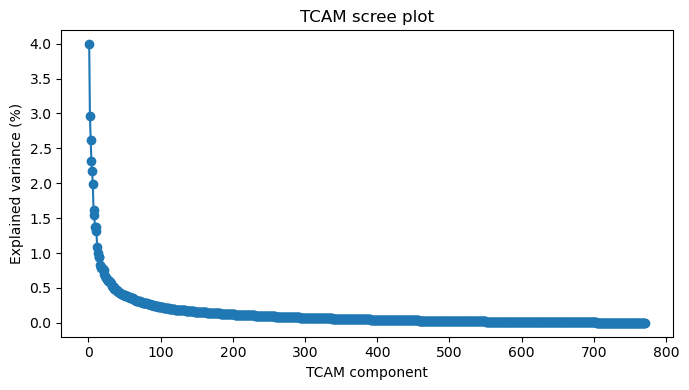

In [ ]:
# ============================================
# [TCAM11] SCREE PLOT
# ============================================
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(expl_var) + 1), expl_var.values * 100, marker="o")
plt.xlabel("TCAM component")
plt.ylabel("Explained variance (%)")
plt.title("TCAM scree plot")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/figures/tcam_scree_plot.png", dpi=200)
plt.show()

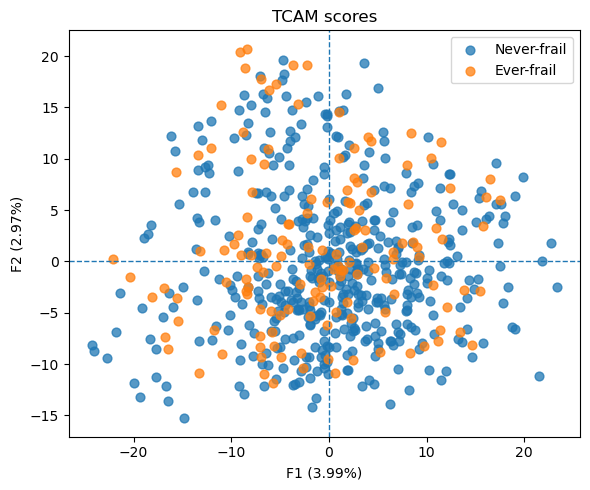

In [ ]:
# ============================================
# [TCAM12] F1 vs F2 per gruppo
# ============================================
plt.figure(figsize=(6, 5))

for grp in ["Never-frail", "Ever-frail"]:
    sub = scores_df[scores_df["frail_group"] == grp]
    plt.scatter(sub["F1"], sub["F2"], s=40, alpha=0.75, label=grp)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel(f"F1 ({expl_var.iloc[0]*100:.2f}%)")
plt.ylabel(f"F2 ({expl_var.iloc[1]*100:.2f}%)")
plt.title("TCAM scores")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTDIR}/figures/tcam_F1_F2_groups.png", dpi=200)
plt.show()

In [ ]:
# ============================================
# [TCAM13] PERMANOVA
# ============================================
from skbio.stats.distance import permanova
from skbio import DistanceMatrix
from sklearn.metrics import pairwise_distances

Q = min(5, scores_df.filter(regex=r"^F\d+$").shape[1])

X_perm = scores_df[[f"F{i+1}" for i in range(Q)]].to_numpy()
groups_perm = scores_df["frail_group"].values
ids_perm = scores_df["Code"].astype(str).tolist()

D = pairwise_distances(X_perm, metric="euclidean")
DM = DistanceMatrix(D, ids=ids_perm)

perm_res = permanova(
    distance_matrix=DM,
    grouping=pd.Series(groups_perm, index=ids_perm),
    permutations=999
)

print(perm_res)

NameError: name 'scores_df' is not defined

## Correlazione 

In [ ]:
# =========================
# [C1] PREPARA MATRICE METABOLITI PER CORRELAZIONE
# =========================
import numpy as np
import pandas as pd

# solo metaboliti finali della parte EDA
X = df_eda[met_cols_eda].apply(pd.to_numeric, errors="coerce").copy()

print("Shape X:", X.shape)
print("Numero metaboliti:", X.shape[1])
print("NaN totali:", int(np.isnan(X.to_numpy()).sum()))

Shape X: (2436, 54)
Numero metaboliti: 54
NaN totali: 0


In [ ]:
# =========================
# [C2] LOG10 DEI METABOLITI (valori <= 0 -> NaN)
# =========================
X_log = np.log10(X.where(X > 0, np.nan))

print("Shape X_log:", X_log.shape)
print("NaN totali dopo log10:", int(np.isnan(X_log.to_numpy()).sum()))
print("Metaboliti con almeno 1 valore valido dopo log10:", int((X_log.notna().sum(axis=0) > 0).sum()))

Shape X_log: (2436, 54)
NaN totali dopo log10: 0
Metaboliti con almeno 1 valore valido dopo log10: 54


In [ ]:
# =========================
# [C3] MATRICE DI CORRELAZIONE
# =========================
import matplotlib.pyplot as plt

METHOD = "spearman"   # consigliato qui

corr = X_log.corr(method=METHOD)



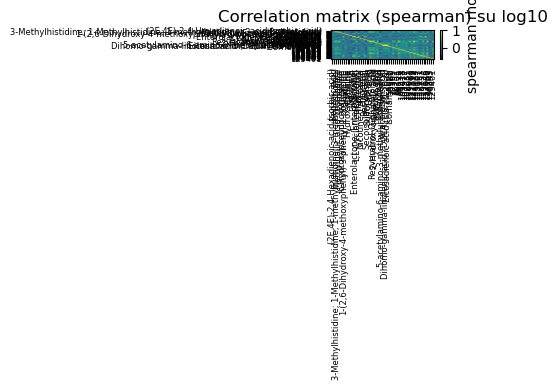

In [ ]:
# =========================
# [C4] HEATMAP DELLA MATRICE DI CORRELAZIONE
# =========================
plt.figure(figsize=(5, 4))
plt.imshow(corr.values, aspect="auto")
plt.colorbar(label=f"{METHOD} rho")
plt.title(f"Correlation matrix ({METHOD}) su log10")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr.index)), corr.index, fontsize=6)
plt.tight_layout()
plt.show()

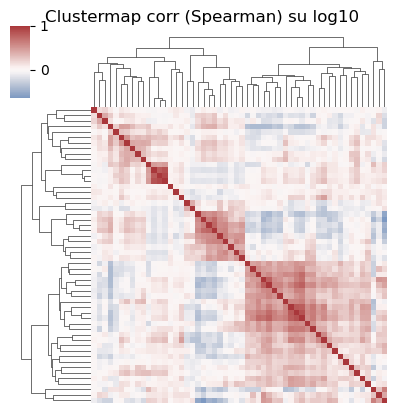

In [ ]:
# =========================
# [C5] CLUSTERMAP DELLA CORRELAZIONE
# =========================
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(
    corr,
    figsize=(4, 4),
    cmap="vlag",
    center=0,
    linewidths=0,
    xticklabels=False,
    yticklabels=False
)
plt.suptitle("Clustermap corr (Spearman) su log10", y=1.02)
plt.show()

In [ ]:
# =========================
# [C6] ESTRAI LE COPPIE DI METABOLITI PIÙ CORRELATE
# =========================
TH = 0.8   # soglia su |rho|

c = corr.copy()

# upper triangle senza diagonale
mask = np.triu(np.ones(c.shape, dtype=bool), k=1)

i, j = np.where(mask)
rho = c.to_numpy()[i, j]

vals = pd.DataFrame({
    "met1": c.index.to_numpy()[i],
    "met2": c.columns.to_numpy()[j],
    "rho": rho
})

vals = vals.dropna(subset=["rho"]).copy()
vals["abs_rho"] = vals["rho"].abs()
vals = vals.sort_values("abs_rho", ascending=False).reset_index(drop=True)

print(f"Coppie totali (uniche): {vals.shape[0]}")
print(f"Coppie con |rho| > {TH}: {int((vals['abs_rho'] > TH).sum())}")

display(vals.head(20))

Coppie totali (uniche): 1431
Coppie con |rho| > 0.8: 5


,met1,met2,rho,abs_rho
0,Arachidonic acid,Dihomo-gamma-linolenic acid (DGLA; cis-20:3n-6),0.908843,0.908843
1,Uric acid,121512,0.864476,0.864476
2,Dihomo-gamma-linolenic acid (DGLA; cis-20:3n-6),Eicosadienoic acid (cis-20:2n-6),0.863708,0.863708
3,Uric acid,133960,0.825727,0.825727
4,Arachidonic acid,Eicosadienoic acid (cis-20:2n-6),0.803491,0.803491
5,121512,133960,0.796143,0.796143
6,2-Hydroxycinnamic acid,88195,0.782559,0.782559
7,88195,121512,0.781937,0.781937
8,Enterodiol,131646,0.758345,0.758345
9,Pinoresinol,131646,0.729095,0.729095


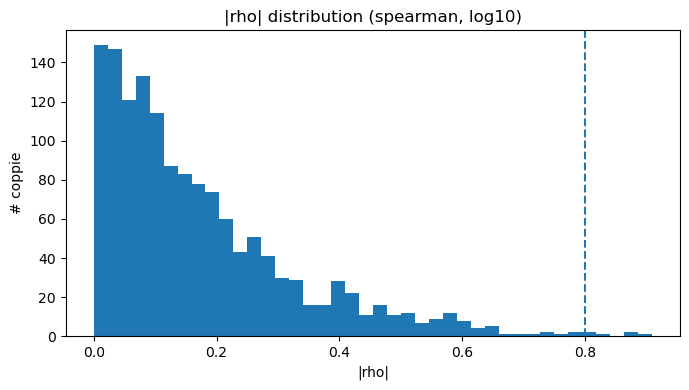

In [ ]:
# =========================
# [C7] ISTOGRAMMA DELLE |CORRELAZIONI|
# =========================
plt.figure(figsize=(7, 4))
plt.hist(vals["abs_rho"].dropna().values, bins=40)
plt.axvline(TH, linestyle="--")
plt.title(f"|rho| distribution ({METHOD}, log10)")
plt.xlabel("|rho|")
plt.ylabel("# coppie")
plt.tight_layout()
plt.show()

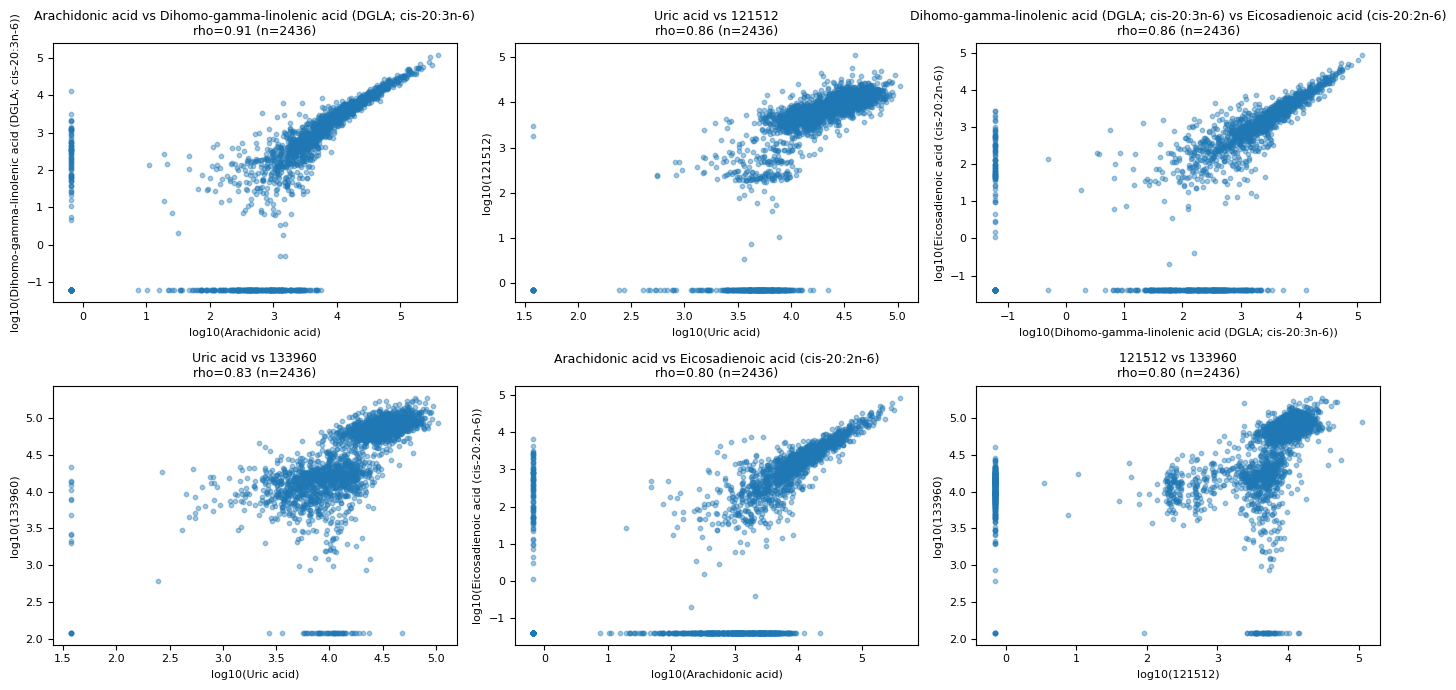

In [ ]:
# =========================
# [C9] SCATTER DELLE COPPIE PIÙ CORRELATE
# =========================
N_SCATTER = 6

pairs_to_plot = vals.sort_values("abs_rho", ascending=False).head(N_SCATTER).copy()

fig, axes = plt.subplots(2, int(np.ceil(N_SCATTER / 2)), figsize=(14, 7))
axes = axes.ravel()

for k, row in enumerate(pairs_to_plot.itertuples(index=False)):
    m1, m2, rho, abs_rho = row.met1, row.met2, row.rho, row.abs_rho
    ax = axes[k]

    x = X_log[m1]
    y = X_log[m2]
    ok = x.notna() & y.notna()

    ax.scatter(x[ok].values, y[ok].values, s=10, alpha=0.4)
    ax.set_title(f"{m1} vs {m2}\nrho={rho:.2f} (n={int(ok.sum())})", fontsize=9)
    ax.set_xlabel(f"log10({m1})", fontsize=8)
    ax.set_ylabel(f"log10({m2})", fontsize=8)
    ax.tick_params(labelsize=8)

for j in range(k + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Spline mixed model

In [ ]:
# =========================
# [FIM1] IMPORT + SETTINGS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from patsy import bs

TIMES = [1,2,3,4]
TIME_TO_YEARS = {1: 0.0, 2: 2.0, 3: 4.0, 4: 8.0}

FRAIL_THR = 0.25
Q_FDR = 0.05

SPLINE_DF = 3
EPS = 1e-9  # per log10(x + EPS) anche se x=0

def fdr_bh(p):
    p = pd.to_numeric(p, errors="coerce")
    out = pd.Series(np.nan, index=p.index, dtype=float)
    m = p.notna() & np.isfinite(p) & (p >= 0) & (p <= 1)
    if m.sum() > 0:
        out.loc[m] = multipletests(p.loc[m].values, method="fdr_bh")[1]
    return out

In [ ]:
# =========================
# [FIM2] BASE LONG: FI + tempo reale (anni) + gruppo ever/never
# Usa df_eda e met_cols_eda (già puliti, con floor inclusi)
# =========================
# NB: se i tuoi metaboliti finali non sono met_cols_eda, cambia qui.
mets = list(met_cols_eda)

base = df_eda[["Code","Time","FI"] + mets].copy()

base["Code"] = pd.to_numeric(base["Code"], errors="coerce").astype(int)
base["Time"] = pd.to_numeric(base["Time"], errors="coerce").astype(int)
base["FI"]   = pd.to_numeric(base["FI"], errors="coerce")

base = base.dropna(subset=["Code","Time","FI"]).copy()
base = base[base["Time"].isin(TIMES)].sort_values(["Code","Time"]).copy()

# tieni solo pazienti completi T1..T4
n_tp = base.groupby("Code")["Time"].nunique()
keep_codes = n_tp[n_tp == len(TIMES)].index
base = base[base["Code"].isin(keep_codes)].copy()

# tempo reale
base["t_years"] = base["Time"].map(TIME_TO_YEARS).astype(float)
base["t"] = base["t_years"] / base["t_years"].max()

# gruppo ever/never frail (da FI)
ever = base.groupby("Code")["FI"].max() >= FRAIL_THR
base["frail_group"] = base["Code"].map(ever.map({True: "Ever-frail", False: "Never-frail"}))
base["frail_group"] = pd.Categorical(base["frail_group"], categories=["Never-frail","Ever-frail"])

print("Righe:", len(base), "| Pazienti:", base["Code"].nunique())
print(base["frail_group"].value_counts())
print(base[["Time","t_years","t"]].drop_duplicates().sort_values("Time"))

Righe: 2436 | Pazienti: 609
frail_group
Never-frail    1828
Ever-frail      608
Name: count, dtype: int64
   Time  t_years     t
0     1      0.0  0.00
1     2      2.0  0.25
2     3      4.0  0.50
3     4      8.0  1.00


In [ ]:
# =========================
# [FIM3] TRASFORMAZIONE + NORMALIZZAZIONE METABOLITI
# log10(x+EPS) + z-score per colonna (usa anche i floor)
# =========================
# forza numerico
base[mets] = base[mets].apply(pd.to_numeric, errors="coerce")

# log10 con floor incluso
Xlog = np.log10(base[mets] + EPS)

# z-score (mean 0, std 1) per metabolita
mu = Xlog.mean(axis=0)
sd = Xlog.std(axis=0, ddof=0).replace(0, np.nan)

Xz = (Xlog - mu) / sd
Xz = Xz.fillna(0.0)  # se sd=0 (raro), mette a 0

# attacca al dataset con nomi safe (evita caratteri strani nelle formule)
met_safe = {m: f"M{i:02d}" for i, m in enumerate(mets)}
base_z = base[["Code","FI","Time","t","t_years","frail_group"]].copy()

for m in mets:
    base_z[met_safe[m]] = Xz[m].astype(float)

print("Metaboliti (safe names):", len(met_safe))
list(met_safe.items())[:5]

Metaboliti (safe names): 54


[('(2E,4E)-2,4-Hexadienoic acid (sorbic acid)', 'M00'),
 ('Benzoic acid', 'M01'),
 ('3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;',
  'M02'),
 ('Methylgallic acid-O-sulphate', 'M03'),
 ('Pyrogallol', 'M04')]

In [ ]:
# =========================
# [FIM4] MODELLO BASE (solo drift + random intercept)
# FI ~ bs(t) + (1|Code)
# =========================
formula0 = f"FI ~ bs(t, df={SPLINE_DF}, degree=3, include_intercept=False)"

md0 = smf.mixedlm(formula0, data=base_z, groups=base_z["Code"])
fit0 = md0.fit(reml=False, method="lbfgs", disp=False)

print(fit0.summary().tables[1])

                                                   Coef. Std.Err.       z  \
Intercept                                          0.105    0.003  34.053   
bs(t, df=3, degree=3, include_intercept=False)[0]  0.029    0.008   3.568   
bs(t, df=3, degree=3, include_intercept=False)[1]  0.029    0.010   2.921   
bs(t, df=3, degree=3, include_intercept=False)[2]  0.086    0.003  33.221   
Group Var                                          0.004    0.006           

                                                   P>|z| [0.025 0.975]  
Intercept                                          0.000  0.099  0.111  
bs(t, df=3, degree=3, include_intercept=False)[0]  0.000  0.013  0.045  
bs(t, df=3, degree=3, include_intercept=False)[1]  0.003  0.009  0.048  
bs(t, df=3, degree=3, include_intercept=False)[2]  0.000  0.081  0.091  
Group Var                                                               


/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



In [ ]:
# =========================
# [FIM5] MODELLO 1: FI ~ metaboliti + bs(t) + (1|Code)
# (associazioni globali, senza gruppi)
# =========================
met_terms = " + ".join(met_safe.values())
formula1 = f"FI ~ {met_terms} + bs(t, df={SPLINE_DF}, degree=3, include_intercept=False)"

md1 = smf.mixedlm(formula1, data=base_z, groups=base_z["Code"])
fit1 = md1.fit(reml=False, method="lbfgs", disp=False)

# estrai p-values solo per metaboliti
p_met = pd.Series({v: float(fit1.pvalues.get(v, np.nan)) for v in met_safe.values()})
q_met = fdr_bh(p_met)

tab1 = pd.DataFrame({
    "metabolite_original": list(met_safe.keys()),
    "metabolite_term": list(met_safe.values()),
    "beta": [float(fit1.params.get(v, np.nan)) for v in met_safe.values()],
    "p": p_met.values,
    "q": q_met.values
}).sort_values("q")

print("Significativi (q<0.05):", int((tab1["q"] < Q_FDR).sum()))
display(tab1.head(30))

Significativi (q<0.05): 3


/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



,metabolite_original,metabolite_term,beta,p,q
23,Hippuric acid,M23,-0.007424,0.000011,0.000573
51,136343,M51,-0.004605,0.000998,0.026957
30,Isorhamnetin,M30,0.005876,0.001900,0.034205
20,Uric acid,M20,0.006342,0.003993,0.053899
1,Benzoic acid,M01,-0.003276,0.007035,0.063312
37,103418,M37,-0.003448,0.006908,0.063312
40,108055,M40,0.002671,0.013806,0.093187
36,88933,M36,-0.002912,0.013485,0.093187
26,5-acetylamino-6-amino-3-methyluracil ((AAMU),M26,-0.003515,0.017768,0.106609
10,Daidzein,M10,0.003998,0.022576,0.121913


In [ ]:
# =========================
# [FIM6] MODELLO 2: FI ~ metaboliti + group + (metaboliti×group) + bs(t) + (1|Code)
# per capire quali metaboliti "pesano" diversamente tra Ever vs Never
# =========================
# main effects metaboliti
met_main = " + ".join(met_safe.values())

# interazioni metabolita:group (Ever-frail vs Never-frail)
met_int = " + ".join([f"{v}:C(frail_group)" for v in met_safe.values()])

formula2 = (
    f"FI ~ {met_main} + C(frail_group) + {met_int} "
    f"+ bs(t, df={SPLINE_DF}, degree=3, include_intercept=False)"
)

md2 = smf.mixedlm(formula2, data=base_z, groups=base_z["Code"])
fit2 = md2.fit(reml=False, method="lbfgs", disp=False)

# p-values per:
# - main metaboliti (effetto in Never-frail, gruppo di riferimento)
# - interazioni (delta effetto in Ever-frail)
p_main = pd.Series({v: float(fit2.pvalues.get(v, np.nan)) for v in met_safe.values()})
p_int  = pd.Series({v: float(fit2.pvalues.get(f"{v}:C(frail_group)[T.Ever-frail]", np.nan)) for v in met_safe.values()})

q_main = fdr_bh(p_main)
q_int  = fdr_bh(p_int)

tab2 = pd.DataFrame({
    "metabolite_original": list(met_safe.keys()),
    "term": list(met_safe.values()),
    "beta_main_Never": [float(fit2.params.get(v, np.nan)) for v in met_safe.values()],
    "q_main": q_main.values,
    "beta_interaction_Ever_minus_Never": [float(fit2.params.get(f"{v}:C(frail_group)[T.Ever-frail]", np.nan)) for v in met_safe.values()],
    "q_interaction": q_int.values
})

tab2["beta_Ever"] = tab2["beta_main_Never"] + tab2["beta_interaction_Ever_minus_Never"]

tab2 = tab2.sort_values(["q_interaction","q_main"])

print("Interazioni significative (q<0.05):", int((tab2["q_interaction"] < Q_FDR).sum()))
print("Main effects significativi (q<0.05):", int((tab2["q_main"] < Q_FDR).sum()))
display(tab2.head(30))

Interazioni significative (q<0.05): 15
Main effects significativi (q<0.05): 0


/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



,metabolite_original,term,beta_main_Never,q_main,beta_interaction_Ever_minus_Never,q_interaction,beta_Ever
18,Secoisolariciresinol,M18,-0.003626,0.136042,0.011383,0.000849,0.007757
23,Hippuric acid,M23,-0.001675,0.672293,-0.015512,0.000849,-0.017186
10,Daidzein,M10,0.005315,0.136042,-0.012896,0.001370,-0.007581
26,5-acetylamino-6-amino-3-methyluracil ((AAMU),M26,-0.001452,0.672293,-0.010251,0.010925,-0.011703
33,77351,M33,-0.002381,0.375442,0.008171,0.013973,0.005790
43,121512,M43,-0.003113,0.589851,0.013522,0.015684,0.010409
1,Benzoic acid,M01,-0.000229,0.922909,-0.007493,0.015735,-0.007722
32,70569,M32,0.001642,0.672293,-0.008914,0.016417,-0.007272
25,Saccharin,M25,0.002678,0.375442,-0.007758,0.021771,-0.005080
4,Pyrogallol,M04,0.001399,0.696570,-0.008765,0.021771,-0.007366


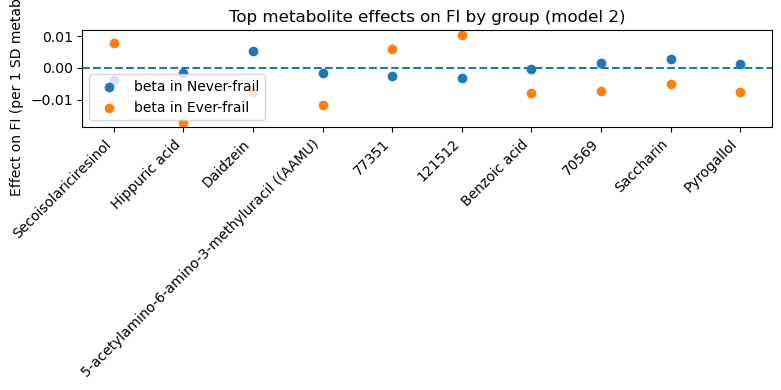

In [ ]:
# =========================
# [FIM7] PLOT: TOP metaboliti (per interazione) — effetto stimato in Never vs Ever
# =========================
TOPK = 10
top_int = tab2.sort_values("q_interaction").head(TOPK)

plt.figure(figsize=(8,4))
x = np.arange(len(top_int))
plt.scatter(x, top_int["beta_main_Never"].values, label="beta in Never-frail")
plt.scatter(x, top_int["beta_Ever"].values, label="beta in Ever-frail")
plt.axhline(0, linestyle="--")
plt.xticks(x, top_int["metabolite_original"].astype(str).values, rotation=45, ha="right")
plt.ylabel("Effect on FI (per 1 SD metabolite)")
plt.title("Top metabolite effects on FI by group (model 2)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# [FIM8] DIAGNOSTICA SEMPLICE: confronto modello base vs con metaboliti
# (AIC più basso = meglio, in generale)
# =========================
print("AIC model0 (time only):", fit0.aic)
print("AIC model1 (+ metabolites):", fit1.aic)
print("AIC model2 (+ group + interactions):", fit2.aic)

AIC model0 (time only): -6871.793419288297
AIC model1 (+ metabolites): -6913.31402281854
AIC model2 (+ group + interactions): -7619.350681516942


## Reg

In [ ]:
# =========================
# [FI-MET1] IMPORT + SETTINGS
# =========================
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, SplineTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance

TIMES = [1,2,3,4]
TIME_TO_YEARS = {1: 0.0, 2: 2.0, 3: 4.0, 4: 8.0}

EPS = 1e-9
N_SPLINES = 5          # flessibilità drift (con 4 timepoint basta piccolo)
ALPHA_RIDGE = 1.0      # regolarizzazione
N_SPLITS = 5
N_REPEATS_PI = 10      # permutation importance repeats (più alto = più stabile)
RANDOM_STATE = 0

In [ ]:
# =========================
# [FI-MET2] PREPARA DATASET LONG (609 soggetti completi)
# =========================
mets = list(met_cols_eda)

df = df_eda[["Code","Time","FI"] + mets].copy()
df["Code"] = pd.to_numeric(df["Code"], errors="coerce").astype(int)
df["Time"] = pd.to_numeric(df["Time"], errors="coerce").astype(int)
df["FI"]   = pd.to_numeric(df["FI"], errors="coerce")

df = df.dropna(subset=["Code","Time","FI"]).copy()
df = df[df["Time"].isin(TIMES)].copy()
df["t_years"] = df["Time"].map(TIME_TO_YEARS).astype(float)

# solo soggetti completi T1..T4
n_tp = df.groupby("Code")["Time"].nunique()
subjects = np.array(sorted(n_tp[n_tp == len(TIMES)].index.astype(int)))
df = df[df["Code"].isin(subjects)].copy()

# forza numerico metaboliti
df[mets] = df[mets].apply(pd.to_numeric, errors="coerce")

# check NaN
if df[mets].isna().any().any():
    raise ValueError("Ci sono NaN nei metaboliti: ricontrolla la fase EDA.")

print("Righe:", len(df), "| Pazienti:", df["Code"].nunique(), "| Metaboliti:", len(mets))
display(df.head())

Righe: 2436 | Pazienti: 609 | Metaboliti: 54


,Code,Time,FI,"(2E,4E)-2,4-Hexadienoic acid (sorbic acid)",Benzoic acid,3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;,Methylgallic acid-O-sulphate,Pyrogallol,6-Hydroxypseudooxynicotine,"1-(2,6-Dihydroxy-4-methoxyphenyl)-3-phenyl-1-propanone",Carnosine,Hydroxycotinine,Caffeine,Daidzein,Enterodiol,Enterolactone; Enterolactone;,"L,L-Cyclo(leucylprolyl)",Pinoresinol,Nicotine-1'-N-oxide,Phloretin,Resveratrol,Secoisolariciresinol,Sulforaphane,Uric acid,Resveratrol-O-glucuronide,2-Hydroxycinnamic acid,Hippuric acid,myo-Inositol,Saccharin,5-acetylamino-6-amino-3-methyluracil ((AAMU),Arachidonic acid,Dihomo-gamma-linolenic acid (DGLA; cis-20:3n-6),Eicosadienoic acid (cis-20:2n-6),Isorhamnetin,53981,70569,77351,86252,88195,88933,103418,103971,107237,108055,119981,121399,121512,124023,125107,127931,128853,129151,131646,133960,136343,96893,125401,t_years
0,9,1,0.060606,234.60,3639.20,6492.7,873.40,1.46,569.60,0.3,176.40,0.02,0.06,2280.9,1602.3,0.04,0.06,54.7,0.06,2698.30,0.06,208.7,10302.30,18152.1,250.10,6964.7,1.2,207.2,0.16,2.26,0.66,0.06,0.04,5.84,52863.60,4199.30,0.02,0.06,1914.10,0.06,0.08,8718.0,4.18,17.70,291.70,6.0,13179.9,318.20,124.80,842.90,0.02,1561.70,0.14,97856.4,0.28,0.88,0.08,0.0
1,9,2,0.060606,0.04,3262.80,6380.9,0.08,3127.70,79.70,0.3,124.30,77.70,0.06,9678.2,144.8,0.04,40.10,0.1,124.70,10247.40,199.50,0.1,10901.60,5879.2,110.40,9701.6,12410.5,85151.5,607.40,80.00,46178.00,12552.10,7353.70,18494.20,1.94,128.70,67.80,747.30,1257.20,0.06,140.90,748.1,678.00,90.30,0.22,5040.8,5254.0,73.70,153.00,60.50,436.90,33.40,43.80,121.3,756.60,3210.50,751.70,2.0
2,9,3,0.060606,1211857.70,996.90,6249.1,0.08,167126.80,0.02,0.3,0.02,98.70,22483.20,996.8,3678.7,522.40,0.06,356848.7,0.06,34104.90,0.06,14146.8,0.02,2505.9,0.52,7834.5,16438.2,68943.1,893.70,1397.00,2824.00,193.70,0.04,14540.00,1.94,257.90,0.02,0.06,0.64,0.06,0.08,1.2,1138.80,0.08,0.22,7044.9,0.7,0.02,0.02,513.60,129.20,0.04,24018.80,40163.9,3476.30,5200.70,0.08,4.0
3,9,4,0.096774,3948.90,0.22,8456.9,0.08,1.46,0.02,3028.5,296.60,1266.40,4002.00,782.5,2056.0,230.50,0.06,13552.6,0.06,0.46,0.06,4977.7,0.02,2757.7,0.52,934.8,22641.0,84477.2,2865.30,7584.40,5492.10,778.70,522.30,30267.60,49571.10,0.36,0.02,99.20,0.64,410.30,0.08,1.2,2088.10,0.08,280.80,10414.4,0.7,0.02,0.02,1632.20,875.80,0.04,3652.00,10240.8,669.10,0.88,0.08,8.0
4,11,1,0.166667,244.70,3542.00,13480.7,56.30,1269.50,0.02,0.3,37.90,0.02,3532.90,3149.8,770.9,0.04,0.06,25.1,0.06,5669.30,0.06,0.1,10304.70,14981.3,68.00,8229.1,105021.7,199112.7,356.70,7361.00,28097.40,6180.90,2719.90,105893.60,1.94,1692.80,0.02,412.20,2093.50,2578.10,240.20,50195.6,4623.90,0.08,781.80,41849.4,8037.6,0.02,129.90,0.04,1093.90,1595.10,745.30,26164.1,0.28,23940.80,713.50,0.0


In [ ]:
# =========================
# [FI-MET3] DEFINISCI FEATURE + PIPELINE (time spline + metaboliti log+zscore)
# =========================
X = df[["t_years"] + mets].copy()
y = df["FI"].to_numpy(dtype=float)
groups = df["Code"].to_numpy()

# log10(x+eps) sui metaboliti
def log_eps(Xm):
    return np.log10(Xm + EPS)

met_pipe = Pipeline(steps=[
    ("log", FunctionTransformer(log_eps, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

time_pipe = Pipeline(steps=[
    ("spline", SplineTransformer(n_knots=N_SPLINES, degree=3, include_bias=False)),
    ("scaler", StandardScaler(with_mean=False))  # sparse-friendly
])

preprocess_full = ColumnTransformer(
    transformers=[
        ("time", time_pipe, ["t_years"]),
        ("met", met_pipe, mets),
    ],
    remainder="drop"
)

preprocess_time_only = ColumnTransformer(
    transformers=[
        ("time", time_pipe, ["t_years"]),
    ],
    remainder="drop"
)

model = Ridge(alpha=ALPHA_RIDGE, random_state=RANDOM_STATE)

pipe_full = Pipeline(steps=[("prep", preprocess_full), ("model", model)])
pipe_time = Pipeline(steps=[("prep", preprocess_time_only), ("model", model)])

In [ ]:
# =========================
# [FI-MET4] CV by subject: RMSE baseline (time-only) vs full (time+metaboliti)
# =========================
cv = GroupKFold(n_splits=N_SPLITS)

rmse_time = []
rmse_full = []

for tr, te in cv.split(X, y, groups=groups):
    Xtr, Xte = X.iloc[tr], X.iloc[te]
    ytr, yte = y[tr], y[te]

    pipe_time.fit(Xtr, ytr)
    pred_time = pipe_time.predict(Xte)
    rmse_time.append(np.sqrt(mean_squared_error(yte, pred_time)))

    pipe_full.fit(Xtr, ytr)
    pred_full = pipe_full.predict(Xte)
    rmse_full.append(np.sqrt(mean_squared_error(yte, pred_full)))

print("RMSE time-only  (mean±std):", float(np.mean(rmse_time)), "±", float(np.std(rmse_time)))
print("RMSE time+met   (mean±std):", float(np.mean(rmse_full)), "±", float(np.std(rmse_full)))
print("ΔRMSE (full - time):", float(np.mean(rmse_full) - np.mean(rmse_time)))

RMSE time-only  (mean±std): 0.07623083504863275 ± 0.003261062562133002
RMSE time+met   (mean±std): 0.07613118639261361 ± 0.003941802970822129
ΔRMSE (full - time): -9.964865601913564e-05


In [ ]:
# =========================
# [FI-MET5] PERMUTATION IMPORTANCE (CV): ranking metaboliti per utilità su RMSE
# =========================
# Importanza = aumento dell'errore quando permuto una feature.
# Qui usiamo scoring = negative RMSE => più negativo = peggio => importance positiva = peggiora rmse.

importances = {m: [] for m in mets}

for fold, (tr, te) in enumerate(cv.split(X, y, groups=groups), start=1):
    Xtr, Xte = X.iloc[tr].copy(), X.iloc[te].copy()
    ytr, yte = y[tr], y[te]

    pipe_full.fit(Xtr, ytr)

    # Permutation importance sul set test del fold
    pi = permutation_importance(
        pipe_full, Xte, yte,
        scoring="neg_root_mean_squared_error",
        n_repeats=N_REPEATS_PI,
        random_state=RANDOM_STATE
    )

    # pi.importances_mean è per le colonne di X (t_years + mets)
    cols = ["t_years"] + mets
    imp = pd.Series(pi.importances_mean, index=cols)

    # prendo solo metaboliti
    for m in mets:
        importances[m].append(float(imp[m]))

# aggrega
rank = pd.DataFrame({
    "metabolite": mets,
    "mean_importance": [np.mean(importances[m]) for m in mets],
    "std_importance":  [np.std(importances[m]) for m in mets]
}).sort_values("mean_importance", ascending=False).reset_index(drop=True)

display(rank.head(20))

,metabolite,mean_importance,std_importance
0,88195,0.001578,0.000618
1,Hippuric acid,0.001236,0.000405
2,Uric acid,0.000852,0.000535
3,88933,0.000725,0.000532
4,myo-Inositol,0.000687,0.000320
5,Methylgallic acid-O-sulphate,0.000546,0.000334
6,121399,0.000523,0.000215
7,136343,0.000449,0.000105
8,Daidzein,0.000372,0.000367
9,103418,0.000363,0.000407


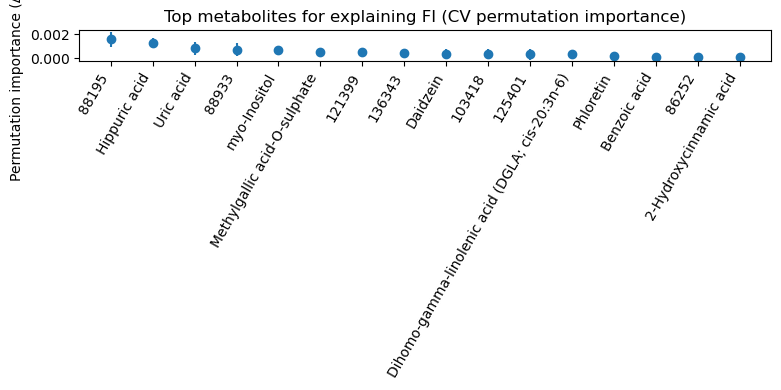

In [ ]:
# =========================
# [FI-MET6] PLOT ranking (Top 15) — quanto peggiora RMSE se rompo il metabolita
# =========================
import matplotlib.pyplot as plt

TOPK = 16
top = rank.head(TOPK).copy()

plt.figure(figsize=(8,4))
plt.errorbar(
    x=np.arange(TOPK),
    y=top["mean_importance"].values,
    yerr=top["std_importance"].values,
    fmt="o"
)
plt.xticks(np.arange(TOPK), top["metabolite"].astype(str).values, rotation=60, ha="right")
plt.ylabel("Permutation importance (Δ neg_RMSE)")
plt.title("Top metabolites for explaining FI (CV permutation importance)")
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# [FI-MET7] COSTRUISCI metaboliti BETWEEN/WITHIN (sui log10)
# =========================
df_bw = df[["Code", "t_years", "FI"] + mets].copy()

# log10 con floor incluso
for m in mets:
    df_bw[m] = np.log10(df_bw[m].astype(float) + EPS)

# between = media soggetto
met_between = df_bw.groupby("Code")[mets].transform("mean")
for m in mets:
    df_bw[f"{m}__between"] = met_between[m]
    df_bw[f"{m}__within"]  = df_bw[m] - df_bw[f"{m}__between"]

# standardizza (global) within/between per confrontare beta
bw_cols = [f"{m}__between" for m in mets] + [f"{m}__within" for m in mets]
df_bw[bw_cols] = (df_bw[bw_cols] - df_bw[bw_cols].mean()) / (df_bw[bw_cols].std(ddof=0) + 1e-12)

display(df_bw.head())

/var/folders/71/8hrhfywn56lfsgx6pcgmxww00000gn/T/ipykernel_52565/3688971714.py:13: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/71/8hrhfywn56lfsgx6pcgmxww00000gn/T/ipykernel_52565/3688971714.py:14: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



,Code,t_years,FI,"(2E,4E)-2,4-Hexadienoic acid (sorbic acid)",Benzoic acid,3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;,Methylgallic acid-O-sulphate,Pyrogallol,6-Hydroxypseudooxynicotine,"1-(2,6-Dihydroxy-4-methoxyphenyl)-3-phenyl-1-propanone",Carnosine,Hydroxycotinine,Caffeine,Daidzein,Enterodiol,Enterolactone; Enterolactone;,"L,L-Cyclo(leucylprolyl)",Pinoresinol,Nicotine-1'-N-oxide,Phloretin,Resveratrol,Secoisolariciresinol,Sulforaphane,Uric acid,Resveratrol-O-glucuronide,2-Hydroxycinnamic acid,Hippuric acid,myo-Inositol,Saccharin,5-acetylamino-6-amino-3-methyluracil ((AAMU),Arachidonic acid,Dihomo-gamma-linolenic acid (DGLA; cis-20:3n-6),Eicosadienoic acid (cis-20:2n-6),Isorhamnetin,53981,70569,77351,86252,88195,88933,103418,103971,107237,108055,119981,121399,121512,124023,125107,127931,128853,129151,131646,133960,136343,96893,125401,"(2E,4E)-2,4-Hexadienoic acid (sorbic acid)__between","(2E,4E)-2,4-Hexadienoic acid (sorbic acid)__within",Benzoic acid__between,Benzoic acid__within,3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;__between,3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;__within,Methylgallic acid-O-sulphate__between,Methylgallic acid-O-sulphate__within,Pyrogallol__between,Pyrogallol__within,6-Hydroxypseudooxynicotine__between,6-Hydroxypseudooxynicotine__within,"1-(2,6-Dihydroxy-4-methoxyphenyl)-3-phenyl-1-propanone__between","1-(2,6-Dihydroxy-4-methoxyphenyl)-3-phenyl-1-propanone__within",Carnosine__between,Carnosine__within,Hydroxycotinine__between,Hydroxycotinine__within,Caffeine__between,Caffeine__within,Daidzein__between,Daidzein__within,Enterodiol__between,Enterodiol__within,Enterolactone; Enterolactone;__between,Enterolactone; Enterolactone;__within,"L,L-Cyclo(leucylprolyl)__between","L,L-Cyclo(leucylprolyl)__within",Pinoresinol__between,Pinoresinol__within,Nicotine-1'-N-oxide__between,Nicotine-1'-N-oxide__within,Phloretin__between,Phloretin__within,Resveratrol__between,Resveratrol__within,Secoisolariciresinol__between,Secoisolariciresinol__within,Sulforaphane__between,Sulforaphane__within,Uric acid__between,Uric acid__within,Resveratrol-O-glucuronide__between,Resveratrol-O-glucuronide__within,2-Hydroxycinnamic acid__between,2-Hydroxycinnamic acid__within,Hippuric acid__between,Hippuric acid__within,myo-Inositol__between,myo-Inositol__within,Saccharin__between,Saccharin__within,5-acetylamino-6-amino-3-methyluracil ((AAMU)__between,5-acetylamino-6-amino-3-methyluracil ((AAMU)__within,Arachidonic acid__between,Arachidonic acid__within,Dihomo-gamma-linolenic acid (DGLA; cis-20:3n-6)__between,Dihomo-gamma-linolenic acid (DGLA; cis-20:3n-6)__within,Eicosadienoic acid (cis-20:2n-6)__between,Eicosadienoic acid (cis-20:2n-6)__within,Isorhamnetin__between,Isorhamnetin__within,53981__between,53981__within,70569__between,70569__within,77351__between,77351__within,86252__between,86252__within,88195__between,88195__within,88933__between,88933__within,103418__between,103418__within,103971__between,103971__within,107237__between,107237__within,108055__between,108055__within,119981__between,119981__within,121399__between,121399__within,121512__between,121512__within,124023__between,124023__within,125107__between,125107__within,127931__between,127931__within,128853__between,128853__within,129151__between,129151__within,131646__between,131646__within,133960__between,133960__within,136343__between,136343__within,96893__between,96893__within,125401__between,125401__within
0,9,0.0,0.060606,2.370328,3.561006,3.812425,2.941213,0.164353,2.755570,-0.522879,2.246499,-1.698970,-1.221849,3.358106,3.204744,-1.397940,-1.221849,1.737987,-1.221849,3.431090,-1.221849,2.319522,4.012934,4.258927,2.398114,3.842902,0.079181,2.316390,-0.795880,0.354108,-0.180456,-1.221849,-1.397940,0.766413,4.723157,3.623177,-1.69897,-1.221849,3.281965,-1.221849,-1.096910,3.940417,0.621176,1.247973,2.464936,0.778151,4.119912,2.502700,2.096215,2.925776,-1.698970,3.193598,-0.

In [ ]:
# =========================
# [FI-MET8] MODELLO INTERPRETABILE (FIX): rinomina colonne safe + OLS cluster
# =========================
import statsmodels.formula.api as smf
from patsy import bs

TOPK_INT = 8
top_mets = rank["metabolite"].head(TOPK_INT).tolist()
print("Top metabolites (interpretation):", top_mets)

# 1) crea mapping metabolita -> nome safe
met_to_safe = {m: f"M{i:02d}" for i, m in enumerate(top_mets)}

# 2) crea un df con colonne safe (between/within) + outcome + time + Code
cols_keep = ["Code", "FI", "t_years"]
df_safe = df_bw[cols_keep].copy()

for m in top_mets:
    s = met_to_safe[m]
    df_safe[f"{s}_between"] = df_bw[f"{m}__between"].values
    df_safe[f"{s}_within"]  = df_bw[f"{m}__within"].values

# 3) costruisci formula con nomi safe
terms = []
for m in top_mets:
    s = met_to_safe[m]
    terms += [f"{s}_between", f"{s}_within"]

formula = "FI ~ " + " + ".join(terms) + " + bs(t_years, df=3, degree=3, include_intercept=False)"

fit = smf.ols(formula, data=df_safe).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_safe["Code"]}
)

print(fit.summary().tables[1])

# 4) tabella risultati (beta, p) con nome metabolita originale
rows = []
for m in top_mets:
    s = met_to_safe[m]
    for kind in ["between", "within"]:
        name = f"{s}_{kind}"
        rows.append({
            "metabolite": m,
            "effect": kind,
            "beta": float(fit.params.get(name, np.nan)),
            "p": float(fit.pvalues.get(name, np.nan)),
        })

res_int = pd.DataFrame(rows)
display(res_int.sort_values(["p"]))

Top metabolites (interpretation): ['88195', 'Hippuric acid', 'Uric acid', '88933', 'myo-Inositol', 'Methylgallic acid-O-sulphate', '121399', '136343']
                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                   0.1064      0.003     37.868      0.000       0.101       0.112
M00_between                                                -0.0101      0.004     -2.669      0.008      -0.018      -0.003
M00_within                                                 -0.0041      0.002     -2.268      0.023      -0.008      -0.001
M01_between                                                -0.0093      0.004     -2.621      0.009      -0.016      -0.002
M01_within                                                 -0.0043      0.002     -2.370      0.018      

,metabolite,effect,beta,p
6,88933,between,-0.010279,0.000139
15,136343,within,-0.004400,0.000171
10,Methylgallic acid-O-sulphate,between,-0.007747,0.001609
4,Uric acid,between,0.009877,0.001684
0,88195,between,-0.010138,0.007608
2,Hippuric acid,between,-0.009253,0.008762
8,myo-Inositol,between,0.007679,0.008964
13,121399,within,0.004660,0.011289
3,Hippuric acid,within,-0.004336,0.017802
1,88195,within,-0.004117,0.023308


In [ ]:
# =========================
# [FI-MET9] FDR (BH) separata per BETWEEN e WITHIN + tabella pulita
# =========================
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

res = res_int.copy()

# BH separato per effect
res["q"] = np.nan
for eff in ["between", "within"]:
    m = res["effect"] == eff
    pvals = res.loc[m, "p"].astype(float).values
    res.loc[m, "q"] = multipletests(pvals, method="fdr_bh")[1]

res = res.sort_values(["effect", "q", "p"]).reset_index(drop=True)

print("Significativi q<0.05 (between):", int(((res["effect"]=="between") & (res["q"]<0.05)).sum()))
print("Significativi q<0.05 (within) :", int(((res["effect"]=="within")  & (res["q"]<0.05)).sum()))

display(res)

Significativi q<0.05 (between): 6
Significativi q<0.05 (within) : 4


,metabolite,effect,beta,p,q
0,88933,between,-0.010279,0.000139,0.001109
1,Methylgallic acid-O-sulphate,between,-0.007747,0.001609,0.004490
2,Uric acid,between,0.009877,0.001684,0.004490
3,88195,between,-0.010138,0.007608,0.011952
4,Hippuric acid,between,-0.009253,0.008762,0.011952
5,myo-Inositol,between,0.007679,0.008964,0.011952
6,136343,between,-0.004778,0.064772,0.074025
7,121399,between,0.003833,0.238151,0.238151
8,136343,within,-0.004400,0.000171,0.001368
9,121399,within,0.004660,0.011289,0.045158


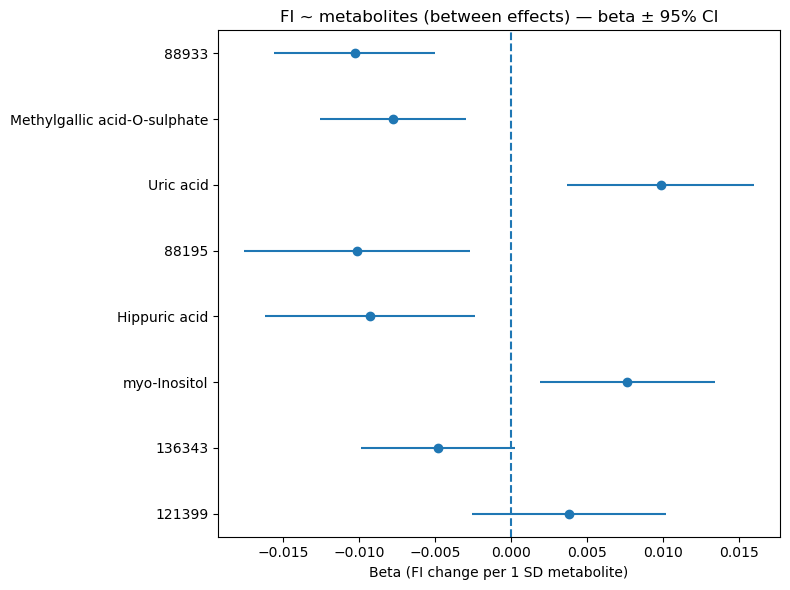

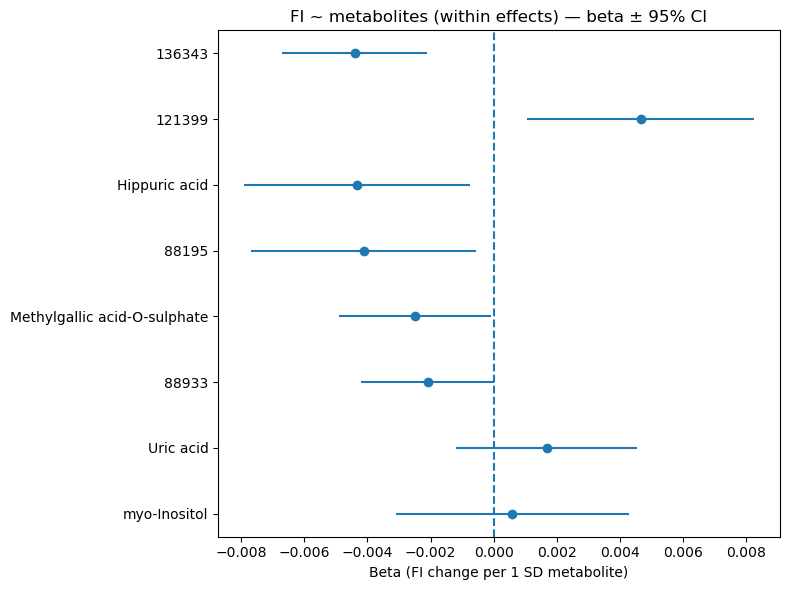

In [ ]:
# =========================
# [FI-MET10] FOREST PLOT beta±1.96*SE (BETWEEN e WITHIN separati)
# usa direttamente fit (OLS cluster) e met_to_safe/top_mets creati nella cella [FI-MET8]
# =========================
import matplotlib.pyplot as plt
import numpy as np

def coef_ci(name):
    b = float(fit.params.get(name, np.nan))
    se = float(fit.bse.get(name, np.nan))
    lo = b - 1.96*se
    hi = b + 1.96*se
    return b, lo, hi

# ricostruisci mapping safe->metabolita
safe_to_met = {v: k for k, v in met_to_safe.items()}

def make_forest(effect, topk=10):
    rows = []
    for met in top_mets:
        s = met_to_safe[met]
        name = f"{s}_{effect}"
        b, lo, hi = coef_ci(name)
        p = float(fit.pvalues.get(name, np.nan))
        rows.append({"metabolite": met, "beta": b, "lo": lo, "hi": hi, "p": p})
    out = pd.DataFrame(rows).sort_values("p").head(topk).reset_index(drop=True)
    return out

forest_between = make_forest("between", topk=min(10, len(top_mets)))
forest_within  = make_forest("within",  topk=min(10, len(top_mets)))

def plot_forest(df_forest, title):
    y = np.arange(len(df_forest))
    plt.figure(figsize=(8, 0.5*len(df_forest) + 2))
    plt.errorbar(df_forest["beta"], y,
                 xerr=[df_forest["beta"]-df_forest["lo"], df_forest["hi"]-df_forest["beta"]],
                 fmt="o")
    plt.axvline(0, linestyle="--")
    plt.yticks(y, df_forest["metabolite"].astype(str))
    plt.xlabel("Beta (FI change per 1 SD metabolite)")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_forest(forest_between, "FI ~ metabolites (between effects) — beta ± 95% CI")
plot_forest(forest_within,  "FI ~ metabolites (within effects) — beta ± 95% CI")